# Model Architectures

from transformers import AutoConfig, AutoModel
import pandas as pd

models = [
    "bert-base-uncased",
    "google/bigbird-roberta-base",
    "distilbert-base-uncased",
    "allenai/longformer-base-4096",
    "monologg/bert-base-cased-goemotions-original"
]

results = []

for model_name in models:
    config = AutoConfig.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    
    
    layers = getattr(config, "num_hidden_layers", "N/A")
    hidden_size = config.hidden_size
    
    intermediate_size = getattr(config, "intermediate_size", hidden_size * 4)
    total_neurons = layers * intermediate_size
    max_seq = config.max_position_embeddings
    params = sum(p.numel() for p in model.parameters()) / 1e6 
    
    results.append({
        "Model": model_name.split('/')[-1],
        "Layers": layers,
        "Hidden Size": hidden_size,
        "Total Neurons": f"{total_neurons:,}",
        "Max Seq": max_seq,
        "Params (M)": f"{params:.1f}M"
    })

df = pd.DataFrame(results)
print(df.to_string(index=False))

# Config

In [2]:
import os
import torch
import json
import logging
import time
import tqdm
import numpy as np, os
import pandas as pd
import pickle
import ast
import torch, transformers
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from transformers import AutoModelForSequenceClassification
from torch.utils.data import DataLoader, Dataset
import neurox.data.extraction.transformers_extractor as transformers_extractor
from neurox.data.writer import ActivationsWriter
import neurox.data.loader as data_loader
from transformers import AutoConfig
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
import neurox.interpretation.linear_probe as linear_probe
import neurox.interpretation.utils as utils
import neurox.analysis.visualization as TransformersVisualizer
from sklearn.model_selection import train_test_split
from IPython.display import display
import neurox.interpretation.probeless as probeless
from neurox.interpretation.probeless import (
    get_neuron_ordering,
    get_neuron_ordering_for_all_tags
)
import ast
from torch.cuda.amp import autocast
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
from matplotlib_venn import venn2
from neurox.interpretation.linear_probe import get_top_neurons
from sklearn.utils import shuffle

from sklearn.model_selection import StratifiedShuffleSplit
from transformers import AutoConfig
from lumia_synapse_api import (
    lumia_layerwise_auc_from_activations, lumia_layerwise_auc_transfer,
    lumia_neuron_ranking_and_mask_from_layer
)



## Logging configuration

In [3]:
os.makedirs("logs", exist_ok=True)

logger = logging.getLogger("synapse_logger")
logger.setLevel(logging.INFO)
logger.propagate = False  # don't rely on root handlers

# Add handlers only if this logger has none (avoid duplicates when re-running cells)
if len(logger.handlers) == 0:
    file_handler = logging.FileHandler("logs/synapse_extraction_csv_pth.log", mode="w")
    file_handler.setLevel(logging.INFO)

    console_handler = logging.StreamHandler()
    console_handler.setLevel(logging.INFO)

    formatter = logging.Formatter("%(asctime)s - %(levelname)s - %(message)s")
    file_handler.setFormatter(formatter)
    console_handler.setFormatter(formatter)

    logger.addHandler(file_handler)
    logger.addHandler(console_handler)

logger.info("🚀 Logging configured")

2026-03-23 19:33:04,070 - INFO - 🚀 Logging configured


## Model configuration

In [4]:
# Select the model (options: "BERT", "BigBird", "DistilBERT", "Longformer")
MODEL = "BigBird"

# Paths based on model name
BASE_PATH = f"data/{MODEL}"
input_csv = f"{BASE_PATH}/{MODEL}_tokens_membership.csv"
output_csv = f"{BASE_PATH}/reduced/{MODEL}_tokens_reduced.csv"
labels_output_path = f"{BASE_PATH}/labels_numeric.txt"
label_mapping_path = f"{BASE_PATH}/labels_mapping.json"
activations_file = f"{BASE_PATH}/activations.json"
weights_path = f"{BASE_PATH}/best_model_{MODEL}.pth"
figs = f"{BASE_PATH}/figs_syn+lum"

NUM_LABELS = 5 # Normal, Bvdl, RansomwarePoC, TheTick, 



MODEL_HF = {
    "BERT": "bert-base-uncased",
    "BigBird": "google/bigbird-roberta-base",
    "DistilBERT": "distilbert-base-uncased",
    "Longformer": "allenai/longformer-base-4096"
}[MODEL]


device = torch.device("cpu")

## Load Model

In [5]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_HF, num_labels=NUM_LABELS)


Some weights of BigBirdForSequenceClassification were not initialized from the model checkpoint at google/bigbird-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [6]:
#use gpu if available
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

state_dict = torch.load(weights_path, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()

print(f"✅ Loaded {MODEL} with pretrained weights on {device}")

/var/folders/y4/zbxddgn52lx1dx5ktc7jch6m0000gn/T/ipykernel_31450/2433573320.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weights_path, map_loc

✅ Loaded BigBird with pretrained weights on cpu


# Dataset

## Load Dataset

In [7]:
# Fast path: reuse reduced dataset if already saved

reduced_ready = (
    os.path.exists(output_csv)
    and os.path.exists(labels_output_path)
    and os.path.exists(label_mapping_path)
)

reduced_ready = False

if reduced_ready:
    logger.info(f"⚡ Reduced dataset found: {output_csv}. Skipping preprocessing.")
    df_reduced = pd.read_csv(output_csv)
    df_reduced["input_ids"] = df_reduced["input_ids"].apply(ast.literal_eval)
    df_reduced["attention_mask"] = df_reduced["attention_mask"].apply(ast.literal_eval)

    with open(labels_output_path, "r") as f:
        labels = [int(line.strip()) for line in f]

    with open(label_mapping_path, "r") as f:
        label_mapping = json.load(f)

    y_task = df_reduced["label"].astype(int).to_numpy()
    y_mem = df_reduced["is_member"].astype(int).to_numpy()

    logger.info(
        f"✅ Loaded reduced dataset -> N={len(df_reduced)} | members={int(y_mem.sum())} | non-members={int((y_mem==0).sum())}"
    )
else:
    logger.info("🔄 Reduced dataset not found. Running full preprocessing...")

2026-03-23 19:33:09,128 - INFO - 🔄 Reduced dataset not found. Running full preprocessing...


In [8]:
with open(label_mapping_path, "r") as f:
        label_mapping = json.load(f)
        
CLASS_NAMES = [None] * len(label_mapping)
for path, idx in label_mapping.items():
    CLASS_NAMES[idx] = os.path.basename(path)
    
PALETTE     = {"baseline": "#5C85C5", "phase3": "#E8803A",
               "phase4a":  "#4BAE8A", "phase4b": "#9B6BC5"}

In [9]:
df_full = pd.read_csv(input_csv)

In [10]:
df_full.head()

,label,input_ids,attention_mask,split,is_member
0,2,"[65, 4094, 100, 14370, 2515, 100, 4094, 100, 1...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",train,1
1,3,"[65, 26957, 100, 14370, 2515, 100, 26957, 100,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",valid,0
2,2,"[65, 21116, 119, 100, 409, 14885, 17094, 110, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",test,0
3,2,"[65, 23136, 100, 1053, 34269, 100, 23136, 100,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",train,1
4,2,"[65, 31591, 100, 15851, 163, 1237, 2536, 100, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",valid,0


In [ ]:
reduction_ratio = 1.0

if not reduced_ready:
    # Load + parse + encode + clean
    os.makedirs(os.path.join(BASE_PATH, "splits"), exist_ok=True)
    os.makedirs(os.path.join(BASE_PATH, "reduced"), exist_ok=True)

    logger.info(f"Loading tokenized dataset from: {input_csv}")
    df_full = pd.read_csv(input_csv)

    def _parse_list_safe(x):
        return ast.literal_eval(x) if isinstance(x, str) else x

    required_cols = ["input_ids", "attention_mask", "label"]
    missing = [c for c in required_cols if c not in df_full.columns]
    if missing:
        raise ValueError(f"Missing required columns in {input_csv}: {missing}")

    df_full["input_ids"] = df_full["input_ids"].apply(_parse_list_safe)
    df_full["attention_mask"] = df_full["attention_mask"].apply(_parse_list_safe)

    label_encoder = LabelEncoder()
    df_full["label"] = label_encoder.fit_transform(df_full["label"].astype(str))

    label_mapping = {str(lbl): int(i) for i, lbl in enumerate(label_encoder.classes_)}
    with open(label_mapping_path, "w") as f:
        json.dump(label_mapping, f, indent=4)

    nan_mask = df_full.isna().any(axis=1)

    def _row_has_empty_list(row):
        return (
            (isinstance(row["input_ids"], list) and len(row["input_ids"]) == 0)
            or (isinstance(row["attention_mask"], list) and len(row["attention_mask"]) == 0)
        )

    empty_mask = df_full.apply(_row_has_empty_list, axis=1)
    combined_mask = nan_mask | empty_mask

    removed = int(combined_mask.sum())
    df_full = df_full[~combined_mask].copy().reset_index(drop=True)
    logger.info(f"Cleaned dataset. Removed rows: {removed}. Remaining rows: {len(df_full)}")

    # Deterministic split (NO SHUFFLING) + membership
    train_size = 0.8
    valid_size = 0.5

    class_counts = df_full["label"].value_counts()
    train_counts = (class_counts * train_size).astype(int)
    valid_test_counts = class_counts - train_counts
    valid_counts = (valid_test_counts * valid_size).astype(int)

    train_parts, valid_parts, test_parts = [], [], []

    for class_label in class_counts.index:
        class_df = df_full[df_full["label"] == class_label]

        tr_n = int(train_counts[class_label])
        va_n = int(valid_counts[class_label])

        train_parts.append(class_df.iloc[:tr_n])
        valid_parts.append(class_df.iloc[tr_n:tr_n + va_n])
        test_parts.append(class_df.iloc[tr_n + va_n:])

    train_df = pd.concat(train_parts, ignore_index=True)
    train_df["split"] = "train"

    valid_df = pd.concat(valid_parts, ignore_index=True)
    valid_df["split"] = "valid"

    test_df = pd.concat(test_parts, ignore_index=True)
    test_df["split"] = "test"

    df_split = pd.concat([train_df, valid_df, test_df], ignore_index=True)
    df_split["is_member"] = (df_split["split"] == "train").astype(int)

    split_dir = os.path.join(BASE_PATH, "splits")
    train_idx = df_split.index[df_split["split"] == "train"].to_numpy()
    valid_idx = df_split.index[df_split["split"] == "valid"].to_numpy()
    test_idx = df_split.index[df_split["split"] == "test"].to_numpy()

    np.save(os.path.join(split_dir, "train_idx.npy"), train_idx)
    np.save(os.path.join(split_dir, "valid_idx.npy"), valid_idx)
    np.save(os.path.join(split_dir, "test_idx.npy"), test_idx)

    with open(os.path.join(split_dir, "split_meta.json"), "w") as f:
        json.dump(
            {
                "train_size": train_size,
                "valid_size_of_remaining": valid_size,
                "n_total": int(len(df_split)),
                "n_train": int(len(train_idx)),
                "n_valid": int(len(valid_idx)),
                "n_test": int(len(test_idx)),
                "protocol": "per-class iloc cuts, no shuffle",
            },
            f,
            indent=4,
        )

    # Reduction preserving (label, is_member)
    if reduction_ratio >= 1.0:
        logger.info("reduction_ratio >= 1.0 -> using the full split dataset without reduction.")
        df_reduced = df_split.copy().reset_index(drop=True)
    else:
        df_split["strat_key"] = (
            df_split["label"].astype(str) + "_" + df_split["is_member"].astype(str)
        )

        try:
            df_reduced, _ = train_test_split(
                df_split,
                train_size=float(reduction_ratio),
                stratify=df_split["strat_key"],
                random_state=42,
            )
        except ValueError as e:
            logger.warning(
                f"Stratified reduction by (label,is_member) failed: {e}. "
                f"Falling back to stratify by label."
            )
            df_reduced, _ = train_test_split(
                df_split,
                train_size=float(reduction_ratio),
                stratify=df_split["label"],
                random_state=42,
            )

        df_reduced = df_reduced.copy().reset_index(drop=True)

    # Persist reduced artifacts
    df_reduced.to_csv(output_csv, index=False)

    with open(labels_output_path, "w") as f:
        for y in df_reduced["label"].astype(int).tolist():
            f.write(f"{y}\n")

    y_task = df_reduced["label"].astype(int).to_numpy()
    y_mem = df_reduced["is_member"].astype(int).to_numpy()

    logger.info(f"✅ Saved reduced dataset to: {output_csv}")
    logger.info(f"✅ Saved numeric labels to: {labels_output_path}")
    logger.info(
        f"✅ Reduced -> N={len(df_reduced)} | "
        f"members={int(y_mem.sum())} | non-members={int((y_mem == 0).sum())}"
    )

2026-03-23 19:26:22,693 - INFO - Loading tokenized dataset from: data/BigBird/BigBird_tokens_membership.csv


KeyboardInterrupt: 

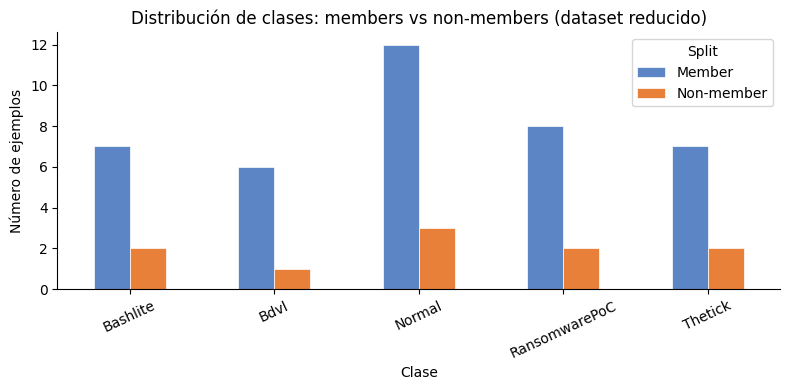

✅ Guardada: data/BigBird/figs_syn+lum/G6_class_distribution.png


In [10]:
# ── Class distribution — members vs non-members ─────────────────────
label_names_map = {v: os.path.basename(k) for k, v in label_mapping.items()}
df_plot = df_reduced.copy()
df_plot["clase"] = df_plot["label"].map(label_names_map)
df_plot["split"] = df_plot["is_member"].map({1: "Member", 0: "Non-member"})

counts = df_plot.groupby(["clase", "split"]).size().unstack(fill_value=0)
counts = counts.reindex([label_names_map[i] for i in sorted(label_names_map)
                          if label_names_map[i] in counts.index])

fig, ax = plt.subplots(figsize=(8, 4))
counts.plot(kind="bar", ax=ax, color=[PALETTE["baseline"], PALETTE["phase3"]],
            edgecolor="white", linewidth=0.5)
ax.set_xlabel("Clase")
ax.set_ylabel("Número de ejemplos")
ax.set_title("Distribución de clases: members vs non-members (dataset reducido)")
ax.tick_params(axis="x", rotation=25)
ax.legend(title="Split")
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(f"{figs}/G6_class_distribution.png", dpi=150)
plt.show()
print(f"✅ Guardada: {figs}/G6_class_distribution.png")

In [11]:
class SyscallDataset(Dataset):
    def __init__(self, dataframe):
        self.data = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        input_ids = torch.tensor(self.data.iloc[idx]["input_ids"], dtype=torch.long)
        attention_mask = torch.tensor(self.data.iloc[idx]["attention_mask"], dtype=torch.long)
        label = torch.tensor(int(self.data.iloc[idx]["label"]), dtype=torch.long)
        return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": label}

dataset = SyscallDataset(df_reduced)
dataloader = DataLoader(dataset, batch_size=4, shuffle=False)

logger.info("✅ Dataloader created")

2026-03-23 11:11:22,808 - INFO - ✅ Dataloader created


# Explainability Module

## Extract or load Activations

In [12]:
if os.path.exists(activations_file):
    logger.info(f"⚡ Activations file found: {activations_file}. Skipping extraction.")
else:
    transformers_extractor.extract_representations(
        model, 
        df_reduced["input_ids"].tolist(),  # Pass preprocessed tokens directly
        activations_file,
        device=device,
    )

    logger.info(f"✅ Activations saved to {activations_file}")


activations, num_layers = data_loader.load_activations(activations_file)
logger.info(f"✅ Loaded activations from {activations_file} with {num_layers} layers")

# Load sentence-level classification data using activations
tokens = data_loader.load_sentence_data(
    output_csv, labels_output_path, activations
)

# Create sentence-level tensors for classification
X, y, mapping = utils.create_tensors(
    tokens,
    activations,
    task_specific_tag="NN",
    task_type="classification"
)

label2idx, idx2label, src2idx, idx2src = mapping
logger.info("✅ Created input/output tensors and label mappings for classification")


2026-03-23 11:11:22,819 - INFO - ⚡ Activations file found: data/BigBird/activations.json. Skipping extraction.
2026-03-23 11:11:22,864 - INFO - ✅ Loaded activations from data/BigBird/activations.json with 12 layers
2026-03-23 11:11:22,881 - INFO - ✅ Created input/output tensors and label mappings for classification


Loading json activations from data/BigBird/activations.json...
50 12.0
Number of tokens:  50
length of source dictionary:  17
length of target dictionary:  5
50
Total instances: 50
['s']
Number of samples:  50
Stats: Labels with their frequencies in the final set
1 7
2 15
3 10
4 9
0 9


## Train linear probe

In [ ]:
# Honest task-probe evaluation on a held-out split
TASK_PROBE_SEED = 42
TASK_PROBE_TEST_SIZE = 0.2

X_train_task, X_test_task, y_train_task, y_test_task = train_test_split(
    X,
    y,
    test_size=TASK_PROBE_TEST_SIZE,
    random_state=TASK_PROBE_SEED,
    stratify=y
)

logger.info(
    f"Task probe split -> train={X_train_task.shape[0]} samples | "
    f"test={X_test_task.shape[0]} samples"
)

# 1) Train only on train split and evaluate on test split
probe_task_eval = linear_probe.train_logistic_regression_probe(
    X_train_task,
    y_train_task,
    lambda_l1=0.001,
    lambda_l2=0.001
)

scores = linear_probe.evaluate_probe(
    probe_task_eval,
    X_test_task,
    y_test_task,
    idx_to_class=idx2label
)

logger.info(f"🎯 Probe evaluation results (held-out): {scores}")

# 2) Retrain on full data only for neuron ranking
probe = linear_probe.train_logistic_regression_probe(
    X,
    y,
    lambda_l1=0.001,
    lambda_l2=0.001
)

top_neurons_probe, per_class_top_neurons = linear_probe.get_top_neurons(
    probe,
    percentage=0.1,
    class_to_idx=label2idx
)

logger.info(f"🔍 Top global neurons: {top_neurons_probe}")
logger.info(f"🔍 Top neurons per class: {per_class_top_neurons}")

Clases en y_train: [0 1 2 3 4]
Training classification probe
Creating model...
Number of training instances: 50
Number of classes: 5


epoch [1/10]: 0it [00:00, ?it/s]

Epoch: [1/10], Loss: 0.0857


epoch [2/10]: 0it [00:00, ?it/s]

Epoch: [2/10], Loss: 0.0683


...

epoch [10/10]: 0it [00:00, ?it/s]

Epoch: [10/10], Loss: 0.0401


Evaluating: 0it [00:00, ?it/s]

2026-03-23 11:11:23,296 - INFO - 🎯 Probe evaluation results: {'__OVERALL__': 0.78, '1': 0.7142857142857143, '2': 0.8, '3': 0.7, '4': 0.8888888888888888, '0': 0.7777777777777778}
2026-03-23 11:11:23,300 - INFO - 🔍 Top global neurons: [8193 6146 8197 ... 4092 8190 4095]
2026-03-23 11:11:23,302 - INFO - 🔍 Top neurons per class: {'1': array([3904, 7796, 9052, 7957, 2994, 8478, 6151, 9083, 7970, 7223, 6577,
       3520, 6320, 5503, 8552, 9096, 7540,   30, 5985, 6994, 3684, 7140,
       7073, 8750, 5088, 7950, 6022, 8583, 8395, 4228, 7339, 6500, 5535,
       6057, 5861, 8219, 5055, 6627, 5254, 7033, 7166, 7877, 8777, 5380,
       9136, 9155, 7874, 5053, 9017, 9173, 6167, 8101, 5566, 6254, 5279,
       3537, 3611, 7203, 3236, 5725, 5660, 6381, 6395, 4398, 8230, 4514,
       8949, 4674, 4724, 6799, 5255, 3574, 7013, 8217, 8578, 7515, 4103,
       2978, 8094, 6607, 7505, 2540, 7055, 6008, 8533, 5149, 4131, 5664,
       8642, 5693, 2187, 3002, 8419, 3034, 4218, 3308, 6442,  629, 3363,
       803

Score (accuracy) of the probe: 0.78


In [14]:
print(X.shape[1])

9216


# Baseline + Reload

In [15]:
df = pd.read_csv(input_csv)

# 🎯 Select 50 random examples and reset index
sample_df = df.sample(n=50, random_state=42).reset_index(drop=True)

# 🧹 Convert "input_ids" and "attention_mask" from string to list format
def parse_list(x):
    return ast.literal_eval(x)

sample_df['input_ids'] = sample_df['input_ids'].apply(parse_list)
sample_df['attention_mask'] = sample_df['attention_mask'].apply(parse_list)

# Encode labels to integers
label_encoder = LabelEncoder()
sample_df['label'] = label_encoder.fit_transform(sample_df['label'])
labels_list = sample_df['label'].tolist()

predictions_list = []
model.eval()
torch.cuda.empty_cache()

def quick_baseline_f1(model, sample_df, labels_list):
    
    model.eval()
    preds = []
    for row in sample_df.itertuples():
        input_ids = torch.tensor(row.input_ids).unsqueeze(0).to(model.device)
        att_mask  = torch.tensor(row.attention_mask).unsqueeze(0).to(model.device)
        with torch.no_grad():
            logits = model(input_ids=input_ids, attention_mask=att_mask).logits
        preds.append(int(logits.argmax(dim=-1)))
    f1w = f1_score(labels_list, preds, average="weighted", zero_division=0)
    logger.info(f"[Baseline Check] Weighted F1-score: {f1w:.4f}")
    return f1w

In [16]:
quick_baseline_f1(model, sample_df, labels_list)

2026-03-23 11:12:46,569 - INFO - [Baseline Check] Weighted F1-score: 0.2392


0.2391565752400667

# Intervention Module

## Function definition

In [17]:
def get_top_k_neurons_exact(probe, percentage: float) -> list[int]:
    """
    Return exactly N = round(total_neurons * percentage) neuron indices, sorted by importance.
    Importance is measured as the sum of absolute values of weights across all output classes.
    """
    weight_matrix = probe.linear.weight.detach().abs()  # [num_classes, num_neurons]
    importance = weight_matrix.sum(dim=0).cpu().numpy()  # [num_neurons]
    total_neurons = len(importance)
    top_n = round(total_neurons * percentage)

    sorted_indices = importance.argsort()[-top_n:]  # Top-N by importance
    return sorted_indices.tolist()

In [18]:
def make_cls_silence_hook(indices):
    """
    Forward hook that zeros out the selected neuron indices in the CLS token.
    It is compatible with:
      - BERT / RoBERTa / BigBird / Longformer (tensor output)
      - DistilBERT (tuple output, usually (hidden_state,) or (hidden_state, attentions))
    """
    idxs = torch.tensor(indices, dtype=torch.long)

    def hook(module, inp, output):
        # 1) Unify output into a `hidden` tensor
        if isinstance(output, tuple):
            if len(output) == 0:
                # Nothing to do
                return output
            hidden = output[0]
        else:
            hidden = output

        # 2) Sanity checks
        if not hasattr(hidden, "dim") or hidden.dim() != 3:
            # Not a (batch, seq_len, hidden) tensor → do nothing
            return output

        if idxs.numel() == 0:
            # No neuron to silence in this layer
            return output

        # 3) Clone and modify CLS token
        new_hidden = hidden.clone()
        cls_token = new_hidden[:, 0, :]           # (batch, hidden_dim)
        cls_token[:, idxs] = 0.0                  # silence selected neurons
        new_hidden[:, 0, :] = cls_token

        # 4) Rebuild structure depending on model
        if isinstance(output, tuple):
            # Keep any extra elements (e.g. attentions) untouched
            return (new_hidden,) + tuple(output[1:])
        else:
            return new_hidden

    return hook

In [19]:

def get_encoder_layers(model):
    if hasattr(model, "bert"):
        return model.bert.encoder.layer
    elif hasattr(model, "longformer"):
        return model.longformer.encoder.layer
    elif hasattr(model, "distilbert"):
        return model.distilbert.transformer.layer
    else:
        raise NotImplementedError("❌ Unsupported model architecture.")

# Membership Inference Evaluation

## Load labels

In [20]:
y_mem = df_reduced["is_member"].astype(int).to_numpy()

L = int(num_layers)
H = int(model.config.hidden_size)
N = len(activations)

A = np.zeros((N, L, H), dtype=np.float32)
for i in range(N):
    flat = activations[i][0]
    A[i] = np.asarray(flat, dtype=np.float32).reshape(L, H)

logger.info(f"✅ Built A with shape {A.shape} (N,L,H)")

out_dir = f"{BASE_PATH}/results"
os.makedirs(out_dir, exist_ok=True)

2026-03-23 11:12:46,594 - INFO - ✅ Built A with shape (50, 12, 768) (N,L,H)


## Calculate per layer AUC 

In [21]:
df_auc, l_star = lumia_layerwise_auc_from_activations(
    activations=A,
    membership_labels=y_mem,
    seed=123,
    test_size=0.2,
    out_csv=f"{out_dir}/auc_by_layer.csv"
)

logger.info(f"✅ Phase1 done. l_star={l_star}")
display(df_auc.head(10))

2026-03-23 11:12:46,640 - INFO - ✅ Phase1 done. l_star=9


,layer_id,auc
9,9,0.5625
1,1,0.5000
8,8,0.5000
11,11,0.5000
0,0,0.4375
2,2,0.4375
3,3,0.4375
4,4,0.4375
5,5,0.4375
6,6,0.4375


## Global Membership Probe

In [ ]:
MEM_PROBE_SEED = 42
MEM_PROBE_TEST_SIZE = 0.2

X_mem = A.reshape(A.shape[0], -1).astype(np.float32)
y_mem = y_mem.astype(int)

X_train_mem, X_test_mem, y_train_mem, y_test_mem = train_test_split(
    X_mem,
    y_mem,
    test_size=MEM_PROBE_TEST_SIZE,
    random_state=MEM_PROBE_SEED,
    stratify=y_mem
)

logger.info(
    f"Membership probe split -> train={X_train_mem.shape[0]} samples | "
    f"test={X_test_mem.shape[0]} samples"
)

# 1) Honest held-out AUC
probe_mem_eval = linear_probe.train_logistic_regression_probe(
    X_train_mem,
    y_train_mem,
    lambda_l1=0.001,
    lambda_l2=0.001
)

auc_mem = linear_probe.evaluate_probe_auc_binary(
    probe_mem_eval,
    X_test_mem,
    y_test_mem,
    positive_class=1
)

print("membership AUC (held-out):", auc_mem)
logger.info(f"Membership AUC (held-out): {auc_mem:.4f}")

# 2) Retrain on full data only for ranking / later analysis
probe_mem = linear_probe.train_logistic_regression_probe(
    X_mem,
    y_mem,
    lambda_l1=0.001,
    lambda_l2=0.001
)

top_idx = linear_probe.get_top_k_neurons_binary(
    probe_mem,
    k=int(round(X_mem.shape[1] * 0.01))
)

print("top-k:", len(top_idx), "example:", top_idx[:10])
logger.info(f"Top-k membership neurons from full-data probe: {len(top_idx)}")

Clases en y_train: [0 1]
Training classification probe
Creating model...
Number of training instances: 50
Number of classes: 2


epoch [1/10]: 0it [00:00, ?it/s]

Epoch: [1/10], Loss: 0.0264


epoch [2/10]: 0it [00:00, ?it/s]

Epoch: [2/10], Loss: 0.0288


...

Epoch: [8/10], Loss: 0.0165


epoch [9/10]: 0it [00:00, ?it/s]

Epoch: [9/10], Loss: 0.0154


epoch [10/10]: 0it [00:00, ?it/s]

Epoch: [10/10], Loss: 0.0136
membership AUC: 0.9275
top-k: 92 example: [5323, 6866, 8067, 7762, 8388, 5889, 7949, 6994, 4347, 4028]


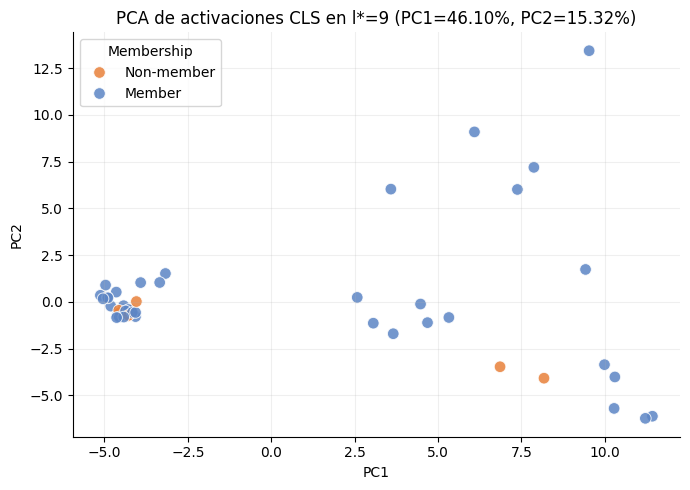

✅ Guardada: data/BigBird/figs_syn+lum/G4_pca_membership_lstar.png


In [23]:
# ── G4 nueva: PCA 2D de activaciones CLS en l* — members vs non-members ─────

from sklearn.decomposition import PCA

layer_star = int(l_star)
X_layer = A[:, layer_star, :]   # [N, 768]

pca = PCA(n_components=2, random_state=123)
X_pca = pca.fit_transform(X_layer)

df_pca = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Membership": np.where(y_mem == 1, "Member", "Non-member")
})

expl_var = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="Membership",
    palette={
        "Member": PALETTE["baseline"],
        "Non-member": PALETTE["phase3"]
    },
    s=70,
    alpha=0.85,
    ax=ax
)

ax.set_title(
    f"PCA de activaciones CLS en l*={layer_star} "
    f"(PC1={expl_var[0]:.2%}, PC2={expl_var[1]:.2%})"
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.grid(alpha=0.2)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(f"{figs}/G4_pca_membership_lstar.png", dpi=150)
plt.show()
print(f"✅ Guardada: {figs}/G4_pca_membership_lstar.png")

## Neuron ranking

## Per layer

In [ ]:
mask_obj = lumia_neuron_ranking_and_mask_from_layer(
    activations=A,
    membership_labels=y_mem,
    layer_id=l_star,
    top_p=0.01,
    seed=123,
    test_size=0.2,
    out_scores_csv=f"{out_dir}/neuron_scores_layer{l_star}.csv",
    out_mask_json=f"{out_dir}/mask_M_layer{l_star}_top0p01.json"
)

logger.info(f"✅ Phase2 done. mask size={mask_obj['top_k']}")


print(mask_obj)
print("---"*6)



2026-03-23 11:12:47,149 - INFO - ✅ Phase2 done. mask size=8


{'layer_id': 9, 'hidden_dim': 768, 'top_p': 0.01, 'top_k': 8, 'indices_global': [6994, 7500, 7365, 7454, 7339, 6950, 7537, 7628]}
------------------


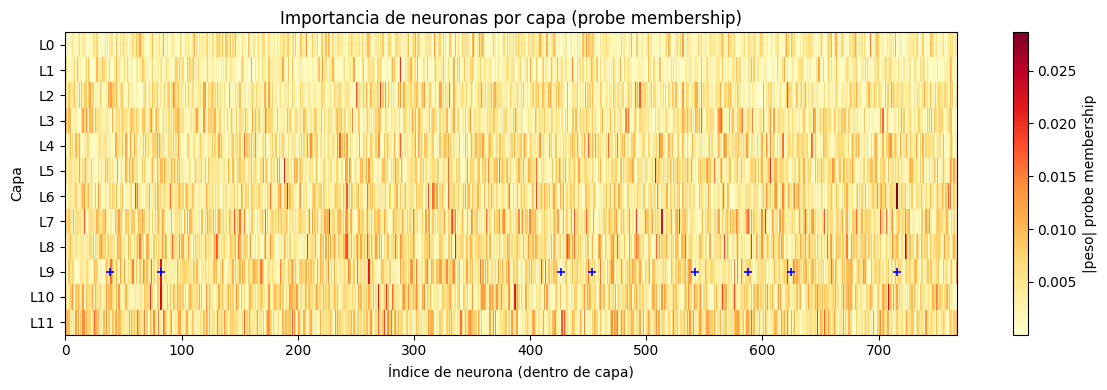

✅ Guardada: data/BigBird/figs_syn+lum/G3_neuron_importance_heatmap.png


In [25]:
# ── G3: Heatmap de importancia de neuronas por capa (probe membership) ───────
W = probe_mem.linear.weight.detach().cpu().numpy()  # [2, 9216]
importance = np.abs(W[1]).reshape(12, 768)          # [L, H]

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(importance, aspect="auto", cmap="YlOrRd", interpolation="nearest")
plt.colorbar(im, ax=ax, label="|peso| probe membership")

# Marcar neuronas de la máscara Phase 3
for g_idx in mask_obj["indices_global"]:
    lay = g_idx // 768
    loc = g_idx % 768
    ax.plot(loc, lay, "b+", markersize=6, markeredgewidth=1.2)

ax.set_yticks(range(12))
ax.set_yticklabels([f"L{i}" for i in range(12)])
ax.set_xlabel("Índice de neurona (dentro de capa)")
ax.set_ylabel("Capa")
ax.set_title("Importancia de neuronas por capa (probe membership)")

plt.tight_layout()
plt.savefig(f"{figs}/G3_neuron_importance_heatmap.png", dpi=150)
plt.show()
print(f"✅ Guardada: {figs}/G3_neuron_importance_heatmap.png")

## Global (Phase 4)

# Model intervention

## Local ($l^*$)

In [26]:
layer_id = int(l_star)

hidden_dim = int(mask_obj["hidden_dim"])
indices_global = [int(x) for x in mask_obj["indices_global"]]
indices_local = [i - layer_id * hidden_dim for i in indices_global]

layers = get_encoder_layers(model)
handle = layers[layer_id].register_forward_hook(make_cls_silence_hook(indices_local))

activations_file_def = f"{BASE_PATH}/activations_DEF_L{layer_id}_p{mask_obj['top_p']}.json"

if os.path.exists(activations_file_def):
    logger.info(f"⚡ Defended activations file found: {activations_file_def}. Skipping extraction.")
else:
    transformers_extractor.extract_representations(
        model,
        df_reduced["input_ids"].tolist(),
        activations_file_def,
        device=device,
    )
    logger.info(f"✅ Defended activations saved to {activations_file_def}")

handle.remove()

activations_def, num_layers_def = data_loader.load_activations(activations_file_def)

L_def = int(num_layers_def)
H_def = int(model.config.hidden_size)
N_def = len(activations_def)

A_def = np.zeros((N_def, L_def, H_def), dtype=np.float32)
for i in range(N_def):
    flat = activations_def[i][0]
    A_def[i] = np.asarray(flat, dtype=np.float32).reshape(L_def, H_def)

2026-03-23 11:12:47,327 - INFO - ⚡ Defended activations file found: data/BigBird/activations_DEF_L9_p0.01.json. Skipping extraction.


Loading json activations from data/BigBird/activations_DEF_L9_p0.01.json...
50 12.0


In [27]:
# Phase 3 — Membership AUC: probe fijo en baseline, evaluado en defended
df_auc_base, best_layer_base = lumia_layerwise_auc_from_activations(
    activations=A, membership_labels=y_mem, seed=123, test_size=0.2
)
df_auc_def, best_layer_def = lumia_layerwise_auc_transfer(
    activations_train=A,
    activations_eval=A_def,
    membership_labels=y_mem, seed=123, test_size=0.2
)

layer_id = int(l_star)
auc_base_l = float(df_auc_base.loc[df_auc_base["layer_id"] == layer_id, "auc"].iloc[0])
auc_def_l  = float(df_auc_def.loc[df_auc_def["layer_id"]  == layer_id, "auc"].iloc[0])

logger.info(f"MEM BASE best_layer={best_layer_base} AUC@l*={auc_base_l:.4f}")
logger.info(f"MEM DEF  best_layer={best_layer_def}  AUC@l*={auc_def_l:.4f}")

2026-03-23 11:12:47,449 - INFO - MEM BASE best_layer=9 AUC@l*=0.5625
2026-03-23 11:12:47,449 - INFO - MEM DEF  best_layer=2  AUC@l*=0.3750


In [28]:
print("=== Phase 3 sanity checks ===")
print("l_star:", int(l_star))
print("A shape:", A.shape)
print("A_def shape:", A_def.shape)
print("y_mem members/nonmembers:", int((y_mem==1).sum()), int((y_mem==0).sum()))

print("\nAUC base per-layer head:")
print(df_auc_base.head(5))

print("\nAUC def per-layer head:")
print(df_auc_def.head(5))

layer_id = int(l_star)
auc_base_l = float(df_auc_base.loc[df_auc_base["layer_id"] == layer_id, "auc"].iloc[0])
auc_def_l  = float(df_auc_def.loc[df_auc_def["layer_id"] == layer_id, "auc"].iloc[0])

print(f"\nAUC@l* baseline: {auc_base_l:.4f}")
print(f"AUC@l* defended : {auc_def_l:.4f}")
print("Delta (base-def):", round(auc_base_l - auc_def_l, 4))

=== Phase 3 sanity checks ===
l_star: 9
A shape: (50, 12, 768)
A_def shape: (50, 12, 768)
y_mem members/nonmembers: 40 10

AUC base per-layer head:
    layer_id     auc
9          9  0.5625
1          1  0.5000
8          8  0.5000
11        11  0.5000
0          0  0.4375

AUC def per-layer head:
   layer_id     auc
2         2  0.6875
3         3  0.5000
1         1  0.3750
4         4  0.3750
5         5  0.3750

AUC@l* baseline: 0.5625
AUC@l* defended : 0.3750
Delta (base-def): 0.1875


In [29]:
def eval_task(model, df, device, batch_size=16, layer_id=None, indices_local=None):
    model.eval()

    handle = None
    if layer_id is not None and indices_local is not None:
        layers = get_encoder_layers(model)
        handle = layers[layer_id].register_forward_hook(make_cls_silence_hook(indices_local))

    y_true = df["label"].astype(int).to_numpy()
    preds_all = []

    with torch.no_grad():
        for start in range(0, len(df), batch_size):
            batch = df.iloc[start:start + batch_size]
            input_ids = torch.tensor(batch["input_ids"].tolist(), dtype=torch.long, device=device)
            attention_mask = torch.tensor(batch["attention_mask"].tolist(), dtype=torch.long, device=device)

            out = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(out.logits, dim=-1).detach().cpu().numpy()
            preds_all.append(preds)

    if handle is not None:
        handle.remove()

    y_pred = np.concatenate(preds_all, axis=0)

    return {
        "acc": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro")),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted")),
        "report": classification_report(y_true, y_pred, digits=4),
    }

layer_id = int(l_star)

task_base = eval_task(model, df_reduced, device, batch_size=16)
task_def  = eval_task(model, df_reduced, device, batch_size=16, layer_id=layer_id, indices_local=indices_local)

logger.info(f"TASK BASE acc={task_base['acc']:.4f} macro_f1={task_base['macro_f1']:.4f} weighted_f1={task_base['weighted_f1']:.4f}")
logger.info(f"TASK DEF  acc={task_def['acc']:.4f} macro_f1={task_def['macro_f1']:.4f} weighted_f1={task_def['weighted_f1']:.4f}")

print("=== TASK BASE report ===")
print(task_base["report"])
print("\n=== TASK DEF report ===")
print(task_def["report"])

print("\n=== PHASE 3 SUMMARY ===")
print(f"l_star={int(l_star)} | top_k={len(indices_local)} | top_p={mask_obj['top_p']}")
print(f"MEM AUC@l* baseline={auc_base_l:.4f} defended={auc_def_l:.4f} delta={auc_base_l-auc_def_l:.4f}")
print(f"TASK macroF1 baseline={task_base['macro_f1']:.4f} defended={task_def['macro_f1']:.4f} delta={task_base['macro_f1']-task_def['macro_f1']:.4f}")

2026-03-23 11:17:23,146 - INFO - TASK BASE acc=0.8400 macro_f1=0.8458 weighted_f1=0.8358
2026-03-23 11:17:23,152 - INFO - TASK DEF  acc=0.8600 macro_f1=0.8684 weighted_f1=0.8590


=== TASK BASE report ===
              precision    recall  f1-score   support

           0     1.0000    0.8889    0.9412         9
           1     1.0000    1.0000    1.0000         7
           2     0.7222    0.8667    0.7879        15
           3     1.0000    1.0000    1.0000        10
           4     0.5714    0.4444    0.5000         9

    accuracy                         0.8400        50
   macro avg     0.8587    0.8400    0.8458        50
weighted avg     0.8395    0.8400    0.8358        50


=== TASK DEF report ===
              precision    recall  f1-score   support

           0     1.0000    0.8889    0.9412         9
           1     1.0000    1.0000    1.0000         7
           2     0.7647    0.8667    0.8125        15
           3     1.0000    1.0000    1.0000        10
           4     0.6250    0.5556    0.5882         9

    accuracy                         0.8600        50
   macro avg     0.8779    0.8622    0.8684        50
weighted avg     0.8619    

## Phase 4 (Global)

### 4A: top K layers

In [ ]:
# Phase 4A - Cell 1: Select top-K layers and build per-layer masks

K = 3
top_p = 0.01
seed = 42
test_size = 0.2

df_auc_sorted = df_auc.sort_values("auc", ascending=False).reset_index(drop=True)
top_layers = df_auc_sorted["layer_id"].head(K).astype(int).tolist()

logger.info(f"Phase 4A -> top_layers={top_layers} (K={K}), top_p={top_p}")

mask_objs = {}
for lid in top_layers:
    mask_obj_k = lumia_neuron_ranking_and_mask_from_layer(
        activations=A,
        membership_labels=y_mem,
        layer_id=int(lid),
        top_p=top_p,
        seed=seed,
        test_size=test_size,
        out_scores_csv=f"{out_dir}/neuron_scores_layer{lid}_P4A.csv",
        out_mask_json=f"{out_dir}/mask_M_layer{lid}_top{str(top_p).replace('.','p')}_P4A.json",
    )
    mask_objs[int(lid)] = mask_obj_k

logger.info(f"✅ Phase 4A masks built for layers: {list(mask_objs.keys())}")

2026-03-23 11:17:23,170 - INFO - Phase 4A -> top_layers=[9, 1, 8] (K=3), top_p=0.01
2026-03-23 11:17:23,188 - INFO - ✅ Phase 4A masks built for layers: [9, 1, 8]


In [31]:
# Phase 4A - Cell 2 (CORREGIDA): Register hooks, extract, remove

def build_local_indices(mask_obj):
    lid = int(mask_obj["layer_id"])
    H = int(mask_obj["hidden_dim"])
    idx_global = [int(x) for x in mask_obj["indices_global"]]
    idx_local = [i - lid * H for i in idx_global]
    if not all(0 <= i < H for i in idx_local):
        raise ValueError(f"Invalid mapping for layer {lid}. Check indices_global.")
    return idx_local

activations_file_def_g = f"{BASE_PATH}/activations_DEF_P4A_K{K}_p{str(top_p).replace('.','p')}.json"

# INVALIDAR cache siempre para Phase 4A (evita cargar fichero de run anterior contaminado)
if os.path.exists(activations_file_def_g):
    os.remove(activations_file_def_g)
    logger.info(f"🗑️ Removed stale cache: {activations_file_def_g}")

layers = get_encoder_layers(model)
handles = []
for lid, mobj in mask_objs.items():
    idx_local = build_local_indices(mobj)
    h = layers[int(lid)].register_forward_hook(make_cls_silence_hook(idx_local))
    handles.append(h)

logger.info(f"🔒 Hooks registered on layers: {list(mask_objs.keys())}")

transformers_extractor.extract_representations(
    model,
    df_reduced["input_ids"].tolist(),
    activations_file_def_g,
    device=device,
)

for h in handles:
    h.remove()
logger.info(f"🔓 Hooks removed. Defended activations saved to {activations_file_def_g}")

2026-03-23 11:17:23,201 - INFO - 🗑️ Removed stale cache: data/BigBird/activations_DEF_P4A_K3_p0p01.json
2026-03-23 11:17:23,201 - INFO - 🔒 Hooks registered on layers: [9, 1, 8]


📤 Saving activations to file
🔄 Extracting CLS token representations from all hidden layers
✅ Sample 0: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 1: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 2: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 3: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 4: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 5: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 6: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 7: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 8: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 9: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 10: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 11: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 12: CLS ac

2026-03-23 11:18:44,802 - INFO - 🔓 Hooks removed. Defended activations saved to data/BigBird/activations_DEF_P4A_K3_p0p01.json


✅ Sample 49: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Activations saved to data/BigBird/activations_DEF_P4A_K3_p0p01.json


In [32]:
# Phase 4A - Cell 3: Load defended activations and build A_def_g

activations_def_g, num_layers_def_g = data_loader.load_activations(activations_file_def_g)

L_g = int(num_layers_def_g)
H_g = int(model.config.hidden_size)
N_g = len(activations_def_g)

A_def_g = np.zeros((N_g, L_g, H_g), dtype=np.float32)
for i in range(N_g):
    flat = activations_def_g[i][0]
    A_def_g[i] = np.asarray(flat, dtype=np.float32).reshape(L_g, H_g)

logger.info(f"✅ Built A_def_g with shape {A_def_g.shape}")

2026-03-23 11:18:44,850 - INFO - ✅ Built A_def_g with shape (50, 12, 768)


Loading json activations from data/BigBird/activations_DEF_P4A_K3_p0p01.json...
50 12.0


In [33]:
# Phase 4A - Cell 4: Membership AUC (probe fijo en baseline, evaluado en defended)

df_auc_base_p4a, best_layer_base_p4a = lumia_layerwise_auc_from_activations(
    activations=A, membership_labels=y_mem, seed=seed, test_size=test_size
)
df_auc_def_p4a, best_layer_def_p4a = lumia_layerwise_auc_transfer(
    activations_train=A,
    activations_eval=A_def_g,
    membership_labels=y_mem, seed=seed, test_size=test_size
)

best_auc_base = float(df_auc_base_p4a["auc"].max())
best_auc_def  = float(df_auc_def_p4a["auc"].max())

logger.info(f"MEM P4A BASE best_layer={best_layer_base_p4a} best_auc={best_auc_base:.4f}")
logger.info(f"MEM P4A DEF  best_layer={best_layer_def_p4a} best_auc={best_auc_def:.4f}")

print("=== Phase 4A membership AUC (top 8 layers) ===")
print("BASE:")
print(df_auc_base_p4a.sort_values("auc", ascending=False).head(8))
print("\nDEF:")
print(df_auc_def_p4a.sort_values("auc", ascending=False).head(8))

2026-03-23 11:18:44,932 - INFO - MEM P4A BASE best_layer=9 best_auc=0.5625
2026-03-23 11:18:44,932 - INFO - MEM P4A DEF  best_layer=9 best_auc=1.0000


=== Phase 4A membership AUC (top 8 layers) ===
BASE:
    layer_id     auc
9          9  0.5625
1          1  0.5000
8          8  0.5000
11        11  0.5000
0          0  0.4375
2          2  0.4375
3          3  0.4375
4          4  0.4375

DEF:
    layer_id     auc
9          9  1.0000
8          8  0.9375
4          4  0.8750
6          6  0.8750
7          7  0.8750
5          5  0.8125
3          3  0.6250
10        10  0.5000


In [34]:
# Phase 4A - Cell 5: Task metrics baseline vs Phase4A defended (hooks on top-K layers)

def eval_task_with_hooks(model, df, device, handles_layers_to_indices, batch_size=16):
    model.eval()

    layers = get_encoder_layers(model)
    handles = []
    for lid, idx_local in handles_layers_to_indices.items():
        handles.append(layers[int(lid)].register_forward_hook(make_cls_silence_hook(idx_local)))

    y_true = df["label"].astype(int).to_numpy()
    preds_all = []

    with torch.no_grad():
        for start in range(0, len(df), batch_size):
            batch = df.iloc[start:start + batch_size]
            input_ids = torch.tensor(batch["input_ids"].tolist(), dtype=torch.long, device=device)
            attention_mask = torch.tensor(batch["attention_mask"].tolist(), dtype=torch.long, device=device)
            out = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(out.logits, dim=-1).detach().cpu().numpy()
            preds_all.append(preds)

    for h in handles:
        h.remove()

    y_pred = np.concatenate(preds_all, axis=0)

    return {
        "acc": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro")),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted")),
        "report": classification_report(y_true, y_pred),
        "y_pred": y_pred,
        "y_true": y_true
    }

# Build dict {layer_id: indices_local}
hooks_map = {lid: build_local_indices(mobj) for lid, mobj in mask_objs.items()}

task_base_p4a = eval_task(model, df_reduced, device, batch_size=16)
task_def_p4a  = eval_task_with_hooks(model, df_reduced, device, hooks_map, batch_size=16)

logger.info(f"TASK P4A BASE: {task_base_p4a}")
logger.info(f"TASK P4A DEF : {task_def_p4a}")

print("=== PHASE 4A SUMMARY ===")
print(f"top_layers={top_layers} | top_p={top_p}")
print(f"MEM best_auc baseline={best_auc_base:.4f} defended={best_auc_def:.4f} delta={best_auc_base-best_auc_def:.4f}")
print(f"TASK macroF1 baseline={task_base_p4a['macro_f1']:.4f} defended={task_def_p4a['macro_f1']:.4f} delta={task_base_p4a['macro_f1']-task_def_p4a['macro_f1']:.4f}")

2026-03-23 11:28:08,316 - INFO - TASK P4A BASE: {'acc': 0.84, 'macro_f1': 0.8458110516934045, 'weighted_f1': 0.8357754010695188, 'report': '              precision    recall  f1-score   support\n\n           0     1.0000    0.8889    0.9412         9\n           1     1.0000    1.0000    1.0000         7\n           2     0.7222    0.8667    0.7879        15\n           3     1.0000    1.0000    1.0000        10\n           4     0.5714    0.4444    0.5000         9\n\n    accuracy                         0.8400        50\n   macro avg     0.8587    0.8400    0.8458        50\nweighted avg     0.8395    0.8400    0.8358        50\n'}
2026-03-23 11:28:08,324 - INFO - TASK P4A DEF : {'acc': 0.84, 'macro_f1': 0.8458110516934045, 'weighted_f1': 0.8357754010695188, 'report': '              precision    recall  f1-score   support\n\n           0       1.00      0.89      0.94         9\n           1       1.00      1.00      1.00         7\n           2       0.72      0.87      0.79        

=== PHASE 4A SUMMARY ===
top_layers=[9, 1, 8] | top_p=0.01
MEM best_auc baseline=0.5625 defended=1.0000 delta=-0.4375
TASK macroF1 baseline=0.8458 defended=0.8458 delta=0.0000


### Phase 4B

In [35]:
# Phase 4B - Cell 1: Map global top indices -> {layer_id: [local_idx...]}

top_p_4b = 0.01
H = int(model.config.hidden_size)
L = int(num_layers)

# Recalcular importancia global desde probe_mem (robusto ante reordenación de celdas)
w = probe_mem.linear.weight.detach().abs()        # [2, L*H]
importance_flat = w.sum(dim=0).cpu().numpy()       # [L*H]
k_global = int(round(L * H * top_p_4b))
top_idx_4b = np.argsort(importance_flat)[-k_global:].tolist()

hooks_map_4b = {}
for g in top_idx_4b:
    layer_id = g // H
    local_idx = g % H
    hooks_map_4b.setdefault(layer_id, []).append(local_idx)
hooks_map_4b = {lid: sorted(set(idxs)) for lid, idxs in hooks_map_4b.items()}

logger.info(f"Phase 4B -> layers_touched={len(hooks_map_4b)} layers={sorted(hooks_map_4b.keys())}")
logger.info(f"Phase 4B -> total_silenced={sum(len(v) for v in hooks_map_4b.values())} expected_k={k_global}")

2026-03-23 11:28:08,376 - INFO - Phase 4B -> layers_touched=11 layers=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
2026-03-23 11:28:08,377 - INFO - Phase 4B -> total_silenced=92 expected_k=92


In [36]:
# Phase 4B - Cell 2: Register hooks and extract defended activations

layers = get_encoder_layers(model)

activations_file_def_4b = f"{BASE_PATH}/activations_DEF_P4B_p{str(top_p_4b).replace('.','p')}.json"

if os.path.exists(activations_file_def_4b):
    os.remove(activations_file_def_4b)
    logger.info(f"🗑️ Removed stale cache: {activations_file_def_4b}")

handles = []
for lid, idxs_local in hooks_map_4b.items():
    handles.append(layers[int(lid)].register_forward_hook(make_cls_silence_hook(idxs_local)))

logger.info(f"🔒 Phase 4B hooks registered on layers: {sorted(hooks_map_4b.keys())}")

transformers_extractor.extract_representations(
    model,
    df_reduced["input_ids"].tolist(),
    activations_file_def_4b,
    device=device,
)

for h in handles:
    h.remove()
logger.info(f"🔓 Phase 4B hooks removed. Saved to {activations_file_def_4b}")

2026-03-23 11:28:08,394 - INFO - 🗑️ Removed stale cache: data/BigBird/activations_DEF_P4B_p0p01.json
2026-03-23 11:28:08,395 - INFO - 🔒 Phase 4B hooks registered on layers: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


📤 Saving activations to file
🔄 Extracting CLS token representations from all hidden layers
✅ Sample 0: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 1: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 2: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 3: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 4: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 5: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 6: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 7: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 8: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 9: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 10: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 11: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 12: CLS ac

2026-03-23 11:38:05,585 - INFO - 🔓 Phase 4B hooks removed. Saved to data/BigBird/activations_DEF_P4B_p0p01.json


✅ Sample 49: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Activations saved to data/BigBird/activations_DEF_P4B_p0p01.json


In [37]:
# Phase 4B - Cell 3: Load defended activations and build A_def_4b

activations_def_4b, num_layers_def_4b = data_loader.load_activations(activations_file_def_4b)

L4 = int(num_layers_def_4b)
H4 = int(model.config.hidden_size)
N4 = len(activations_def_4b)

A_def_4b = np.zeros((N4, L4, H4), dtype=np.float32)
for i in range(N4):
    flat = activations_def_4b[i][0]
    A_def_4b[i] = np.asarray(flat, dtype=np.float32).reshape(L4, H4)

logger.info(f"✅ Built A_def_4b with shape {A_def_4b.shape}")

2026-03-23 11:38:05,675 - INFO - ✅ Built A_def_4b with shape (50, 12, 768)


Loading json activations from data/BigBird/activations_DEF_P4B_p0p01.json...
50 12.0


In [38]:
# Phase 4B - Cell 4: Membership AUC (probe fijo en baseline, evaluado en defended)

df_auc_base_4b, best_layer_base_4b = lumia_layerwise_auc_from_activations(
    activations=A, membership_labels=y_mem, seed=123, test_size=0.2
)
df_auc_def_4b, best_layer_def_4b = lumia_layerwise_auc_transfer(
    activations_train=A,
    activations_eval=A_def_4b,
    membership_labels=y_mem, seed=123, test_size=0.2
)

best_auc_base = float(df_auc_base_4b["auc"].max())
best_auc_def  = float(df_auc_def_4b["auc"].max())

layer_id = int(l_star)
auc_base_l = float(df_auc_base_4b.loc[df_auc_base_4b["layer_id"] == layer_id, "auc"].iloc[0])
auc_def_l  = float(df_auc_def_4b.loc[df_auc_def_4b["layer_id"]  == layer_id, "auc"].iloc[0])

logger.info("=== Phase 4B membership summary ===")
logger.info(f"BASE best_layer={best_layer_base_4b} best_auc={best_auc_base:.4f} AUC@l*={auc_base_l:.4f}")
logger.info(f"DEF  best_layer={best_layer_def_4b} best_auc={best_auc_def:.4f} AUC@l*={auc_def_l:.4f}")
logger.info(f"Delta best_auc={best_auc_base-best_auc_def:.4f} | Delta AUC@l*={auc_base_l-auc_def_l:.4f}")

logger.info("Top layers BASE:\n" + str(df_auc_base_4b.sort_values("auc", ascending=False).head(8)))
logger.info("Top layers DEF:\n"  + str(df_auc_def_4b.sort_values("auc", ascending=False).head(8)))

2026-03-23 11:38:05,791 - INFO - === Phase 4B membership summary ===
2026-03-23 11:38:05,791 - INFO - BASE best_layer=9 best_auc=0.5625 AUC@l*=0.5625
2026-03-23 11:38:05,792 - INFO - DEF  best_layer=2 best_auc=0.6875 AUC@l*=0.3750
2026-03-23 11:38:05,792 - INFO - Delta best_auc=-0.1250 | Delta AUC@l*=0.1875
2026-03-23 11:38:05,794 - INFO - Top layers BASE:
    layer_id     auc
9          9  0.5625
1          1  0.5000
8          8  0.5000
11        11  0.5000
0          0  0.4375
2          2  0.4375
3          3  0.4375
4          4  0.4375
2026-03-23 11:38:05,795 - INFO - Top layers DEF:
   layer_id     auc
2         2  0.6875
3         3  0.3750
4         4  0.3750
6         6  0.3750
7         7  0.3750
9         9  0.3750
1         1  0.3125
5         5  0.3125


In [39]:
# Phase 4B - Cell 5: Task metrics baseline vs defended

def eval_task_with_hooks_map(model, df, device, hooks_map, batch_size=16):
    model.eval()
    layers = get_encoder_layers(model)
    handles = []
    for lid, idxs_local in hooks_map.items():
        handles.append(layers[int(lid)].register_forward_hook(make_cls_silence_hook(idxs_local)))

    y_true = df["label"].astype(int).to_numpy()
    preds_all = []

    with torch.no_grad():
        for start in range(0, len(df), batch_size):
            batch = df.iloc[start:start + batch_size]
            input_ids = torch.tensor(batch["input_ids"].tolist(), dtype=torch.long, device=device)
            attention_mask = torch.tensor(batch["attention_mask"].tolist(), dtype=torch.long, device=device)
            out = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(out.logits, dim=-1).detach().cpu().numpy()
            preds_all.append(preds)

    for h in handles:
        h.remove()

    y_pred = np.concatenate(preds_all, axis=0)

    return {
        "acc": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro")),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted")),
        "y_pred": y_pred,
        "y_true": y_true,
    }

task_base_4b = eval_task(model, df_reduced, device, batch_size=16)
task_def_4b = eval_task_with_hooks_map(model, df_reduced, device, hooks_map_4b, batch_size=16)

logger.info("=== Phase 4B task summary ===")
logger.info(f"BASE: {task_base_4b}")
logger.info(f"DEF : {task_def_4b}")

logger.info("=== PHASE 4B FINAL SUMMARY ===")
logger.info(
    f"top_p={top_p_4b} | total_silenced={sum(len(v) for v in hooks_map_4b.values())} | "
    f"layers_touched={len(hooks_map_4b)}"
)
logger.info(f"MEM best_auc baseline={best_auc_base:.4f} defended={best_auc_def:.4f} delta={best_auc_base-best_auc_def:.4f}")
logger.info(f"TASK macroF1 baseline={task_base_4b['macro_f1']:.4f} defended={task_def_4b['macro_f1']:.4f} delta={task_base_4b['macro_f1']-task_def_4b['macro_f1']:.4f}")

2026-03-23 11:50:56,347 - INFO - === Phase 4B task summary ===
2026-03-23 11:50:56,350 - INFO - BASE: {'acc': 0.84, 'macro_f1': 0.8458110516934045, 'weighted_f1': 0.8357754010695188, 'report': '              precision    recall  f1-score   support\n\n           0     1.0000    0.8889    0.9412         9\n           1     1.0000    1.0000    1.0000         7\n           2     0.7222    0.8667    0.7879        15\n           3     1.0000    1.0000    1.0000        10\n           4     0.5714    0.4444    0.5000         9\n\n    accuracy                         0.8400        50\n   macro avg     0.8587    0.8400    0.8458        50\nweighted avg     0.8395    0.8400    0.8358        50\n'}
2026-03-23 11:50:56,351 - INFO - DEF : {'acc': 0.84, 'macro_f1': 0.8458110516934045, 'weighted_f1': 0.8357754010695188, 'y_pred': array([3, 2, 2, 2, 0, 4, 2, 0, 3, 3, 2, 2, 2, 0, 3, 3, 2, 2, 1, 1, 3, 0,
       2, 2, 3, 4, 4, 2, 1, 0, 2, 2, 1, 4, 3, 4, 2, 0, 3, 2, 4, 4, 0, 1,
       1, 2, 3, 1, 2, 0]), '

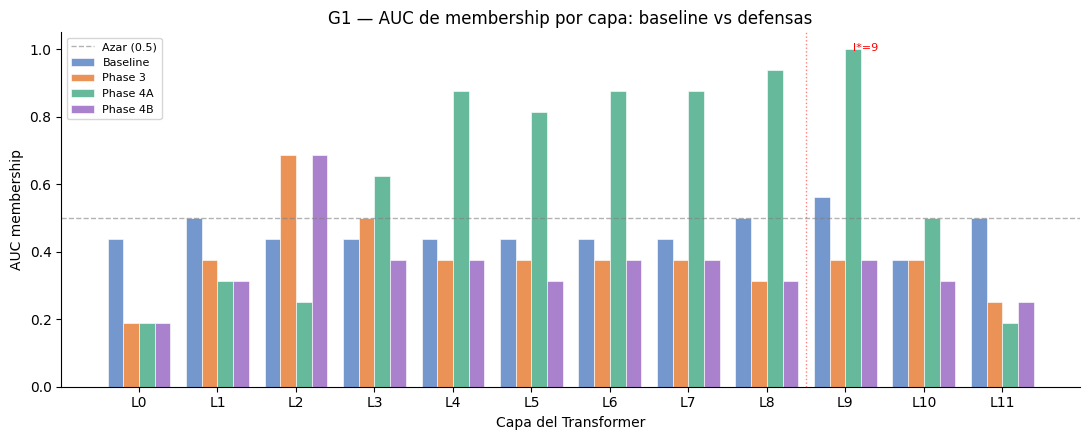

✅ Guardada: data/BigBird/figs_syn+lum/G1_auc_por_capa.png


In [40]:
# ── G1: AUC membership por capa — baseline vs todas las defensas ─────────────
fig, ax = plt.subplots(figsize=(11, 4.5))

layers_x = list(range(12))

# Reindexar todos los df_auc para tener las 12 capas en orden
def auc_series(df):
    s = df.set_index("layer_id")["auc"].reindex(layers_x, fill_value=0.5)
    return s.values

base_vals = auc_series(df_auc_base)
def3_vals = auc_series(df_auc_def)
def4a_vals = auc_series(df_auc_def_p4a)
def4b_vals = auc_series(df_auc_def_4b)

width = 0.2
xs = np.array(layers_x)

bars = [
    (base_vals,  "Baseline",  PALETTE["baseline"]),
    (def3_vals,  "Phase 3",   PALETTE["phase3"]),
    (def4a_vals, "Phase 4A",  PALETTE["phase4a"]),
    (def4b_vals, "Phase 4B",  PALETTE["phase4b"]),
]
for i, (vals, label, color) in enumerate(bars):
    ax.bar(xs + (i - 1.5) * width, vals, width=width, label=label,
           color=color, alpha=0.85, edgecolor="white", linewidth=0.5)

ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, alpha=0.6, label="Azar (0.5)")
ax.axvline(int(l_star) - 0.5, color="red", linestyle=":", linewidth=1, alpha=0.5)
ax.text(int(l_star) + 0.1, ax.get_ylim()[1] * 0.97, f"l*={int(l_star)}",
        color="red", fontsize=8, va="top")

ax.set_xticks(layers_x)
ax.set_xticklabels([f"L{i}" for i in layers_x])
ax.set_xlabel("Capa del Transformer")
ax.set_ylabel("AUC membership")
ax.set_ylim(0, 1.05)
ax.set_title("G1 — AUC de membership por capa: baseline vs defensas")
ax.legend(loc="upper left", fontsize=8)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(f"{figs}/G1_auc_por_capa.png", dpi=150)
plt.show()
print(f"✅ Guardada: {figs}/G1_auc_por_capa.png")

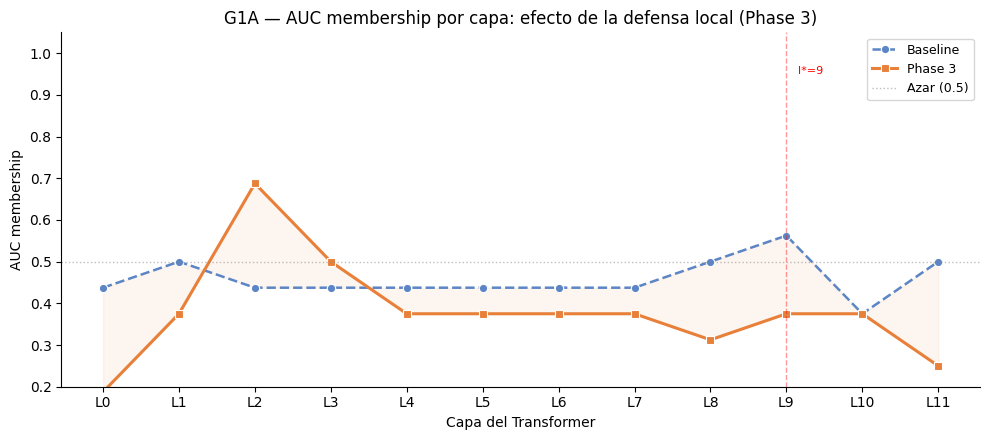

✅ Guardada: data/BigBird/figs_syn+lum/G1A_auc_phase3.png


In [41]:
# ── G1A: AUC por capa como líneas — baseline vs Phase 3 ──────────────────────
fig, ax = plt.subplots(figsize=(10, 4.5))

layers_x = list(range(12))

def auc_series(df):
    return df.set_index("layer_id")["auc"].reindex(layers_x, fill_value=0.5).values

series = [
    (auc_series(df_auc_base),     "Baseline",  PALETTE["baseline"], "o--", 1.8),
    (auc_series(df_auc_def),      "Phase 3",   PALETTE["phase3"],   "s-",  2.2),
]

for vals, label, color, style, lw in series:
    ax.plot(layers_x, vals, style, color=color, label=label,
            linewidth=lw, markersize=6, markeredgecolor="white", markeredgewidth=0.8)

ax.axhline(0.5, color="gray", linestyle=":", linewidth=1, alpha=0.5, label="Azar (0.5)")
ax.axvline(int(l_star), color="red", linestyle="--", linewidth=1, alpha=0.4)
ax.text(int(l_star) + 0.15, 0.97, f"l*={int(l_star)}", color="red", fontsize=8, va="top")

ax.fill_between(layers_x, auc_series(df_auc_base), auc_series(df_auc_def),
                alpha=0.08, color=PALETTE["phase3"])

ax.set_xticks(layers_x)
ax.set_xticklabels([f"L{i}" for i in layers_x])
ax.set_ylim(0.2, 1.05)
ax.set_xlabel("Capa del Transformer")
ax.set_ylabel("AUC membership")
ax.set_title("G1A — AUC membership por capa: efecto de la defensa local (Phase 3)")
ax.legend(fontsize=9)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(f"{figs}/G1A_auc_phase3.png", dpi=150)
plt.show()
print(f"✅ Guardada: {figs}/G1A_auc_phase3.png")

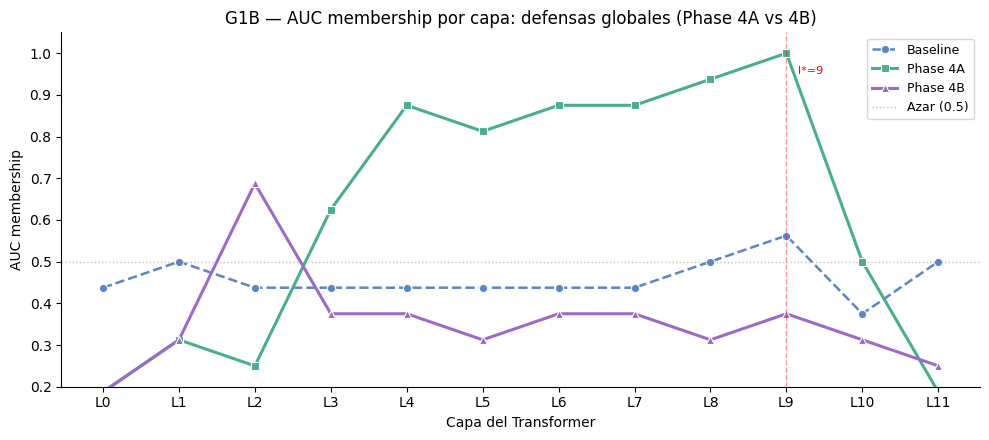

✅ Guardada: data/BigBird/figs_syn+lum/G1B_auc_phase4.png


In [42]:
# ── G1B: AUC por capa como líneas — baseline vs Phase 4A vs Phase 4B ─────────
fig, ax = plt.subplots(figsize=(10, 4.5))

series = [
    (auc_series(df_auc_base),     "Baseline",  PALETTE["baseline"], "o--", 1.8),
    (auc_series(df_auc_def_p4a),  "Phase 4A",  PALETTE["phase4a"],  "s-",  2.2),
    (auc_series(df_auc_def_4b),   "Phase 4B",  PALETTE["phase4b"],  "^-",  2.2),
]

for vals, label, color, style, lw in series:
    ax.plot(layers_x, vals, style, color=color, label=label,
            linewidth=lw, markersize=6, markeredgecolor="white", markeredgewidth=0.8)

ax.axhline(0.5, color="gray", linestyle=":", linewidth=1, alpha=0.5, label="Azar (0.5)")
ax.axvline(int(l_star), color="red", linestyle="--", linewidth=1, alpha=0.4)
ax.text(int(l_star) + 0.15, 0.97, f"l*={int(l_star)}", color="red", fontsize=8, va="top")

ax.set_xticks(layers_x)
ax.set_xticklabels([f"L{i}" for i in layers_x])
ax.set_ylim(0.2, 1.05)
ax.set_xlabel("Capa del Transformer")
ax.set_ylabel("AUC membership")
ax.set_title("G1B — AUC membership por capa: defensas globales (Phase 4A vs 4B)")
ax.legend(fontsize=9)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(f"{figs}/G1B_auc_phase4.png", dpi=150)
plt.show()
print(f"✅ Guardada: {figs}/G1B_auc_phase4.png")

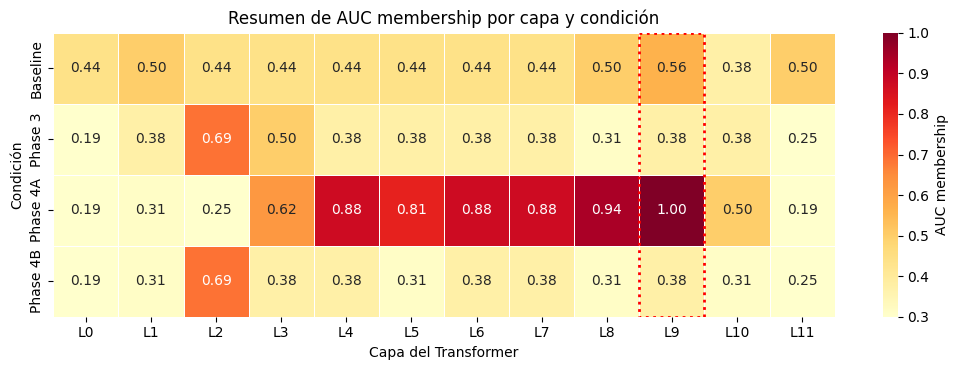

✅ Guardada: data/BigBird/figs_syn+lum/G1C_auc_heatmap_summary.png


In [43]:
# ── G1C: Heatmap resumen AUC membership por capa y condición ──

layers_x = list(range(12))

def auc_series(df):
    return (
        df.set_index("layer_id")["auc"]
        .reindex(layers_x, fill_value=0.5)
        .values
    )

heatmap_df = pd.DataFrame(
    [
        auc_series(df_auc_base),
        auc_series(df_auc_def),
        auc_series(df_auc_def_p4a),
        auc_series(df_auc_def_4b),
    ],
    index=["Baseline", "Phase 3", "Phase 4A", "Phase 4B"],
    columns=[f"L{i}" for i in layers_x]
)

fig, ax = plt.subplots(figsize=(10.5, 3.8))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    vmin=0.3,
    vmax=1.0,
    linewidths=0.5,
    cbar_kws={"label": "AUC membership"},
    ax=ax
)

ax.set_title("Resumen de AUC membership por capa y condición")
ax.set_xlabel("Capa del Transformer")
ax.set_ylabel("Condición")

# marcar l*
ax.add_patch(plt.Rectangle((int(l_star), 0), 1, len(heatmap_df.index),
                           fill=False, edgecolor="red", lw=2, linestyle=":"))

plt.tight_layout()
plt.savefig(f"{figs}/G1C_auc_heatmap_summary.png", dpi=150)
plt.show()
print(f"✅ Guardada: {figs}/G1C_auc_heatmap_summary.png")

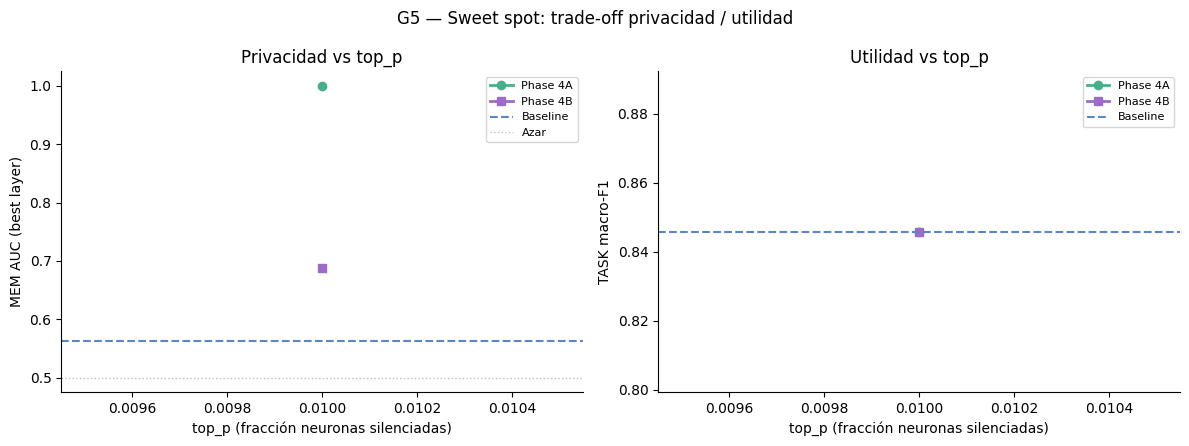

✅ Guardada: data/BigBird/figs_syn+lum/G5_sweet_spot_tradeoff.png
⚠️  Añade más puntos a top_p_vals cuando hagas el sweep completo


In [44]:
# ── G5: Sweet spot — trade-off privacidad/utilidad (placeholder con top_p=0.01)
# Cuando hagas el sweep, añade más puntos a estas listas
top_p_vals  = [0.01]

# Phase 4A
mem_auc_4a  = [float(df_auc_def_p4a["auc"].max())]
task_f1_4a  = [task_def_p4a["macro_f1"]]

# Phase 4B
mem_auc_4b  = [float(df_auc_def_4b["auc"].max())]
task_f1_4b  = [task_def_4b["macro_f1"]]

# Baseline (referencia fija)
mem_auc_base_val  = float(df_auc_base["auc"].max())
task_f1_base_val  = task_base_p4a["macro_f1"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel izquierdo: MEM AUC vs top_p
ax = axes[0]
ax.plot(top_p_vals, mem_auc_4a, "o-", color=PALETTE["phase4a"], label="Phase 4A", linewidth=2)
ax.plot(top_p_vals, mem_auc_4b, "s-", color=PALETTE["phase4b"], label="Phase 4B", linewidth=2)
ax.axhline(mem_auc_base_val, color=PALETTE["baseline"], linestyle="--", linewidth=1.5, label="Baseline")
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1, alpha=0.5, label="Azar")
ax.set_xlabel("top_p (fracción neuronas silenciadas)")
ax.set_ylabel("MEM AUC (best layer)")
ax.set_title("Privacidad vs top_p")
ax.legend(fontsize=8)
sns.despine(ax=ax)

# Panel derecho: TASK F1 vs top_p
ax = axes[1]
ax.plot(top_p_vals, task_f1_4a, "o-", color=PALETTE["phase4a"], label="Phase 4A", linewidth=2)
ax.plot(top_p_vals, task_f1_4b, "s-", color=PALETTE["phase4b"], label="Phase 4B", linewidth=2)
ax.axhline(task_f1_base_val, color=PALETTE["baseline"], linestyle="--", linewidth=1.5, label="Baseline")
ax.set_xlabel("top_p (fracción neuronas silenciadas)")
ax.set_ylabel("TASK macro-F1")
ax.set_title("Utilidad vs top_p")
ax.legend(fontsize=8)
sns.despine(ax=ax)

fig.suptitle("G5 — Sweet spot: trade-off privacidad / utilidad", fontsize=12)
plt.tight_layout()
plt.savefig(f"{figs}/G5_sweet_spot_tradeoff.png", dpi=150)
plt.show()
print(f"✅ Guardada: {figs}/G5_sweet_spot_tradeoff.png")
print("⚠️  Añade más puntos a top_p_vals cuando hagas el sweep completo")

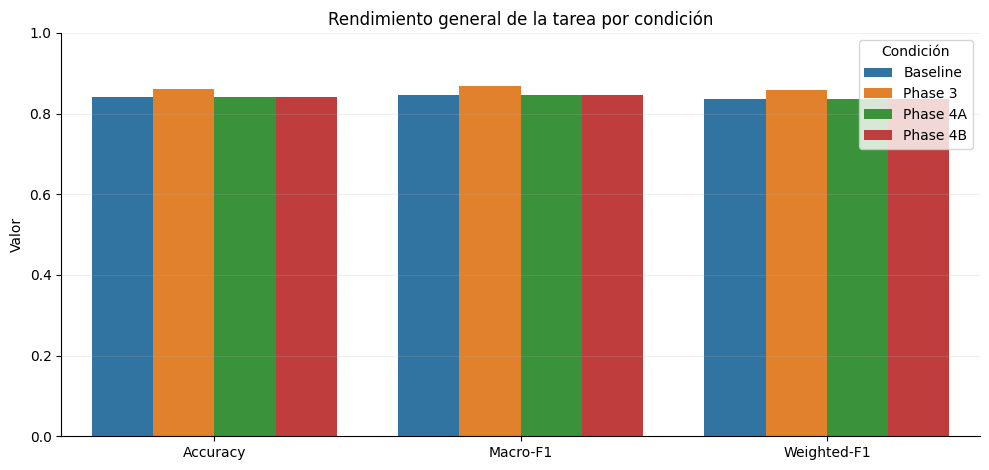

✅ Guardada: data/BigBird/figs_syn+lum/G_perf_task_metrics.png


,Condición,Accuracy,Macro-F1,Weighted-F1
0,Baseline,0.84,0.845811,0.835775
1,Phase 3,0.86,0.868382,0.859044
2,Phase 4A,0.84,0.845811,0.835775
3,Phase 4B,0.84,0.845811,0.835775


In [45]:
# ── G_perf: Rendimiento general de tarea por condición ───────────────────────

perf_df = pd.DataFrame([
    {
        "Condición": "Baseline",
        "Accuracy": task_base["acc"],
        "Macro-F1": task_base["macro_f1"],
        "Weighted-F1": task_base["weighted_f1"],
    },
    {
        "Condición": "Phase 3",
        "Accuracy": task_def["acc"],
        "Macro-F1": task_def["macro_f1"],
        "Weighted-F1": task_def["weighted_f1"],
    },
    {
        "Condición": "Phase 4A",
        "Accuracy": task_def_p4a["acc"],
        "Macro-F1": task_def_p4a["macro_f1"],
        "Weighted-F1": task_def_p4a["weighted_f1"],
    },
    {
        "Condición": "Phase 4B",
        "Accuracy": task_def_4b["acc"],
        "Macro-F1": task_def_4b["macro_f1"],
        "Weighted-F1": task_def_4b["weighted_f1"],
    },
])

perf_long = perf_df.melt(id_vars="Condición", var_name="Métrica", value_name="Valor")

fig, ax = plt.subplots(figsize=(10, 4.8))
sns.barplot(data=perf_long, x="Métrica", y="Valor", hue="Condición", ax=ax)

ax.set_title("Rendimiento general de la tarea por condición")
ax.set_ylabel("Valor")
ax.set_xlabel("")
ax.set_ylim(0, 1.0)
ax.grid(axis="y", alpha=0.2)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(f"{figs}/G_perf_task_metrics.png", dpi=150)
plt.show()
print(f"✅ Guardada: {figs}/G_perf_task_metrics.png")
display(perf_df)

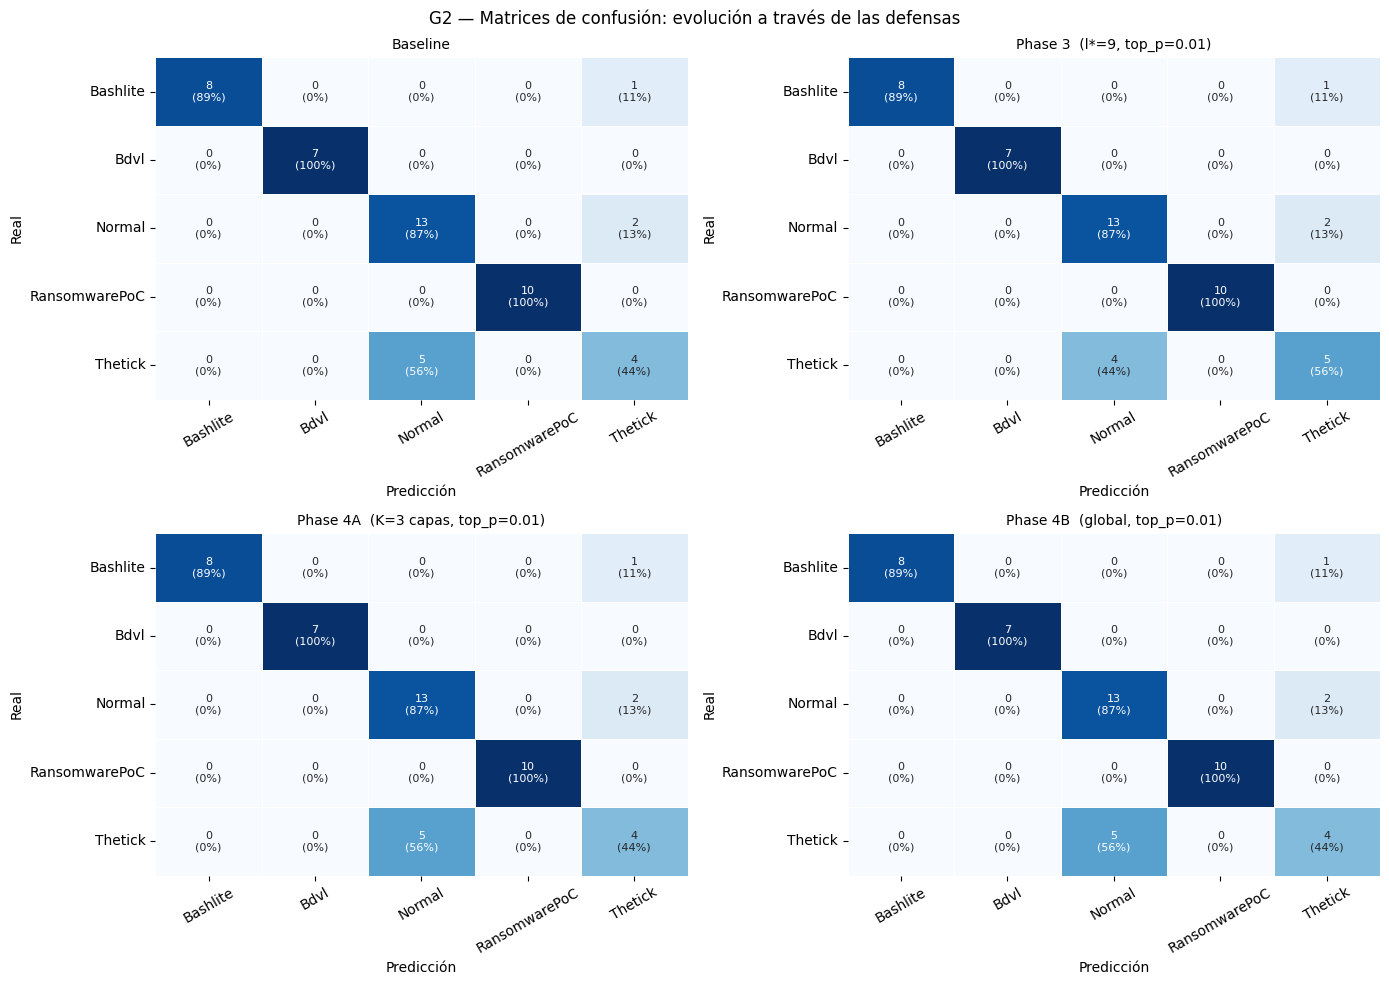

✅ Guardada: data/BigBird/figs_syn+lum/G2_confusion_matrix.png


In [46]:
# ── G2: Matrices de confusión — baseline, Phase 3, 4A, 4B ────────────────────

def get_preds(model, df, device, layer_id=None, indices_local=None):
    model.eval()
    handle = None
    if layer_id is not None:
        layers = get_encoder_layers(model)
        handle = layers[layer_id].register_forward_hook(
            make_cls_silence_hook(indices_local))
    y_true, y_pred = [], []
    with torch.no_grad():
        for start in range(0, len(df), 16):
            batch = df.iloc[start:start+16]
            ids  = torch.tensor(batch["input_ids"].tolist(),      dtype=torch.long, device=device)
            mask = torch.tensor(batch["attention_mask"].tolist(), dtype=torch.long, device=device)
            out  = model(input_ids=ids, attention_mask=mask)
            y_pred.extend(torch.argmax(out.logits, dim=-1).cpu().numpy())
            y_true.extend(batch["label"].astype(int).tolist())
    if handle: handle.remove()
    return np.array(y_true), np.array(y_pred)

y_true_b,  y_pred_b  = get_preds(model, df_reduced, device)
y_true_d3, y_pred_d3 = get_preds(model, df_reduced, device,
                                  layer_id=int(l_star),
                                  indices_local=indices_local)
y_true_4a = task_def_p4a["y_true"]
y_pred_4a = task_def_p4a["y_pred"]
y_true_4b = task_def_4b["y_true"]
y_pred_4b = task_def_4b["y_pred"]

scenarios = [
    (y_true_b,  y_pred_b,  "Baseline"),
    (y_true_d3, y_pred_d3, f"Phase 3  (l*={int(l_star)}, top_p=0.01)"),
    (y_true_4a, y_pred_4a, f"Phase 4A  (K=3 capas, top_p=0.01)"),
    (y_true_4b, y_pred_4b, f"Phase 4B  (global, top_p=0.01)"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (yt, yp, title) in zip(axes.flatten(), scenarios):
    cm = confusion_matrix(yt, yp)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    annot = np.array([[f"{cm[i,j]}\n({cm_pct[i,j]:.0%})"
                       for j in range(5)] for i in range(5)])
    sns.heatmap(cm_pct, annot=annot, fmt="", cmap="Blues", ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, cbar=False, vmin=0, vmax=1,
                annot_kws={"size": 8})
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis="x", rotation=30)

fig.suptitle("G2 — Matrices de confusión: evolución a través de las defensas", fontsize=12)
plt.tight_layout()
plt.savefig(f"{figs}/G2_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Guardada: {figs}/G2_confusion_matrix.png")

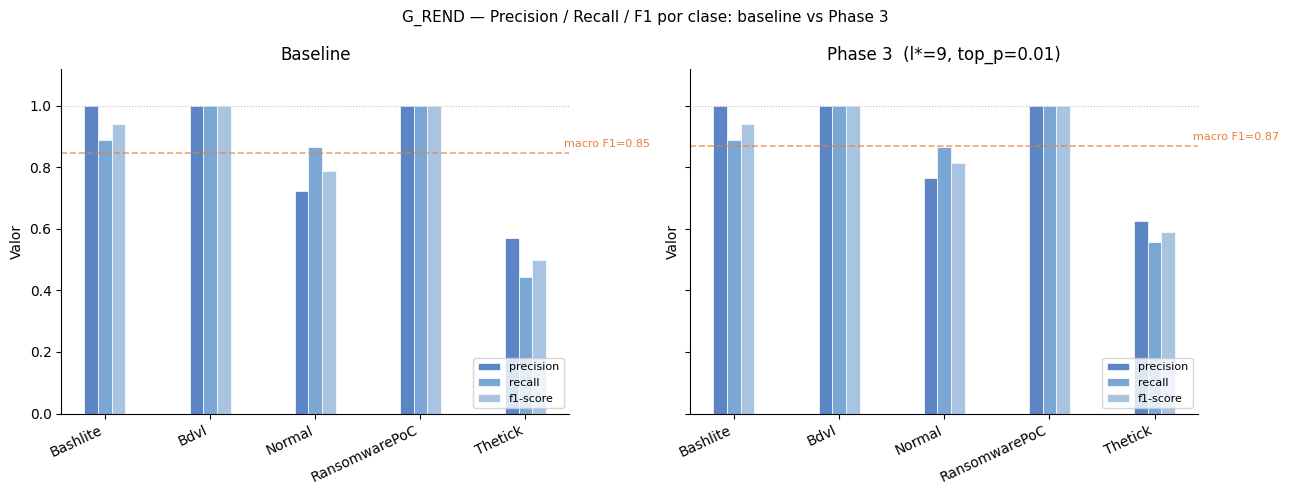

✅ Guardada: data/BigBird/figs_syn+lum/G_REND_performance_by_class.png


In [47]:
# ── G_REND: Rendimiento general — precision/recall/F1 por clase ───────────────
from sklearn.metrics import classification_report
import pandas as pd

report_base = classification_report(y_true_b, y_pred_b,
                                     target_names=CLASS_NAMES, output_dict=True)
report_def = classification_report(y_true_d3, y_pred_d3,
                                    target_names=CLASS_NAMES, output_dict=True)

metrics = ["precision", "recall", "f1-score"]
x = np.arange(len(CLASS_NAMES))
width = 0.13

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

colors = ["#5C85C5", "#7BA7D4", "#A8C4E0"]

for ax, report, title in [
    (axes[0], report_base, "Baseline"),
    (axes[1], report_def,  f"Phase 3  (l*={int(l_star)}, top_p=0.01)"),
]:
    for m_i, (metric, color) in enumerate(zip(metrics, colors)):
        vals = [report[cls][metric] for cls in CLASS_NAMES]
        ax.bar(x + m_i * width, vals, width=width, label=metric,
               color=color, edgecolor="white", linewidth=0.5)

    ax.set_xticks(x + width)
    ax.set_xticklabels(CLASS_NAMES, rotation=25, ha="right")
    ax.set_ylim(0, 1.12)
    ax.set_ylabel("Valor")
    ax.set_title(title)
    ax.axhline(1.0, color="gray", linestyle=":", linewidth=0.8, alpha=0.5)

    # Añadir macro avg como línea de referencia
    macro_f1 = report["macro avg"]["f1-score"]
    ax.axhline(macro_f1, color=PALETTE["phase3"], linestyle="--",
               linewidth=1.2, alpha=0.7)
    ax.text(len(CLASS_NAMES) - 0.5, macro_f1 + 0.02,
            f"macro F1={macro_f1:.2f}", color=PALETTE["phase3"], fontsize=8)

    ax.legend(fontsize=8, loc="lower right")
    sns.despine(ax=ax)

fig.suptitle("G_REND — Precision / Recall / F1 por clase: baseline vs Phase 3", fontsize=11)
plt.tight_layout()
plt.savefig(f"{figs}/G_REND_performance_by_class.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Guardada: {figs}/G_REND_performance_by_class.png")

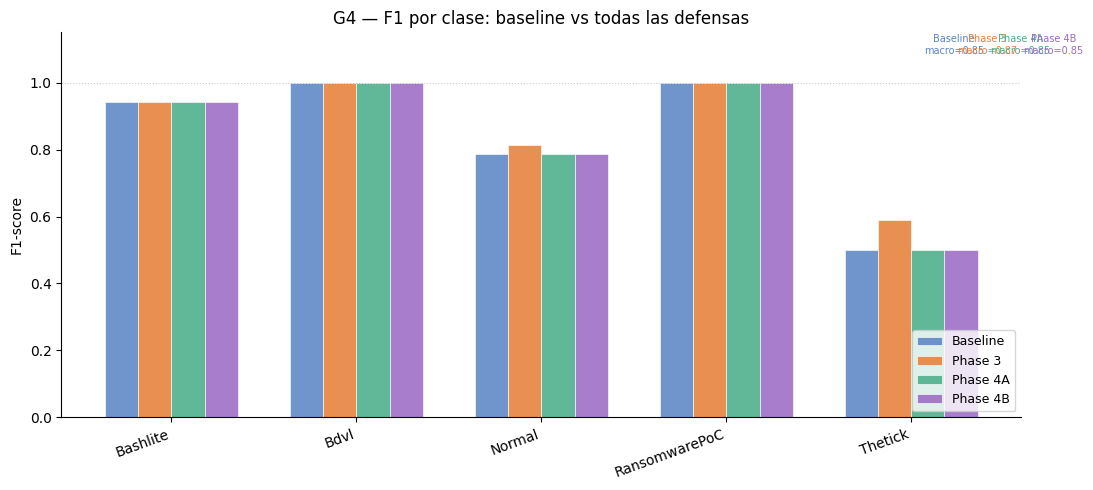

✅ Guardada: data/BigBird/figs_syn+lum/G4_f1_por_clase.png


In [48]:
# ── G4: F1 por clase — todas las fases ───────────────────────────────────────
from sklearn.metrics import classification_report

reports = {
    "Baseline":  classification_report(y_true_b,  y_pred_b,  target_names=CLASS_NAMES, output_dict=True),
    "Phase 3":   classification_report(y_true_d3, y_pred_d3, target_names=CLASS_NAMES, output_dict=True),
    "Phase 4A":  classification_report(y_true_4a, y_pred_4a, target_names=CLASS_NAMES, output_dict=True),
    "Phase 4B":  classification_report(y_true_4b, y_pred_4b, target_names=CLASS_NAMES, output_dict=True),
}

phase_colors = {
    "Baseline": PALETTE["baseline"],
    "Phase 3":  PALETTE["phase3"],
    "Phase 4A": PALETTE["phase4a"],
    "Phase 4B": PALETTE["phase4b"],
}

x = np.arange(len(CLASS_NAMES))
n_phases = len(reports)
width = 0.18
offsets = np.linspace(-(n_phases - 1) / 2, (n_phases - 1) / 2, n_phases) * width

fig, ax = plt.subplots(figsize=(11, 5))

for (phase, report), offset in zip(reports.items(), offsets):
    f1_vals = [report[cls]["f1-score"] for cls in CLASS_NAMES]
    ax.bar(x + offset, f1_vals, width=width, label=phase,
           color=phase_colors[phase], edgecolor="white",
           linewidth=0.5, alpha=0.88)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=20, ha="right")
ax.set_ylim(0, 1.15)
ax.set_ylabel("F1-score")
ax.set_title("G4 — F1 por clase: baseline vs todas las defensas")
ax.axhline(1.0, color="gray", linestyle=":", linewidth=0.8, alpha=0.4)
ax.legend(fontsize=9, loc="lower right")
sns.despine(ax=ax)

# Añadir macro F1 de cada fase como texto encima del gráfico
for i, (phase, report) in enumerate(reports.items()):
    macro = report["macro avg"]["f1-score"]
    ax.text(len(CLASS_NAMES) - 0.5 + offsets[i], 1.08,
            f"{phase}\nmacro={macro:.2f}",
            ha="center", va="bottom", fontsize=7,
            color=phase_colors[phase])

plt.tight_layout()
plt.savefig(f"{figs}/G4_f1_por_clase.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Guardada: {figs}/G4_f1_por_clase.png")

# Sweep experiments

In [49]:
# ═══════════════════════════════════════════════════════════════════════════
# SWEEP EXPERIMENT
# ═══════════════════════════════════════════════════════════════════════════
#
# Objetivo: medir el trade-off privacidad/utilidad barriendo top_p.
#
# Experimentos por cada valor de top_p:
#   E1 — Phase 3   : dirigido, solo l*          → defensa mínima
#   E2 — Phase 4A  : dirigido, top-K capas      → defensa media
#   E3 — Phase 4B  : dirigido, espacio global   → defensa máxima
#   E4 — Control   : aleatorio, mismo k que 4B  → baseline de comparación
#
# Métricas recogidas por experimento:
#   - MEM AUC best layer (transferability probe)
#   - MEM AUC @ l* (capa original más vulnerable)
#   - TASK macro-F1 y accuracy
#   - AUC por cada capa (para reconstruir G1 post-hoc)
#
# Guardado:
#   - Checkpoint JSON + CSV tras cada top_p (no se pierde nada si se cae)
#   - Carpeta con timestamp — nunca sobreescribe runs anteriores
#   - Activaciones defendidas en JSON por si hacen falta para análisis posterior
# ═══════════════════════════════════════════════════════════════════════════

import json
import numpy as np
import pandas as pd
from datetime import datetime
from collections import defaultdict

# ── Configuración ─────────────────────────────────────────────────────────────
TOP_P_VALUES = [0.001, 0.005, 0.01, 0.02, 0.05, 0.10, 0.20, 0.40, 0.65, 0.80]
K_LAYERS     = 4       # número de capas para Phase 4A
SEED         = 42
TEST_SIZE    = 0.2
RUN_TS       = datetime.now().strftime("%Y%m%d_%H%M%S")

sweep_dir = f"{BASE_PATH}/sweep_{RUN_TS}"
os.makedirs(sweep_dir, exist_ok=True)
logger.info(f"Sweep started — run: {RUN_TS}")
logger.info(f"top_p values: {TOP_P_VALUES}")
logger.info(f"Output dir: {sweep_dir}")

# ── Dimensiones del modelo ────────────────────────────────────────────────────
L = int(num_layers)
H = int(model.config.hidden_size)

# ── Importancia global de neuronas para membership (desde probe_mem) ──────────
# probe_mem fue entrenado sobre X_mem = A.reshape(N, L*H) → predice y_mem
# Se suma el |peso| de ambas clases para obtener importancia global por neurona
importance_flat = probe_mem.linear.weight.detach().abs().sum(dim=0).cpu().numpy()  # [L*H]

# ── Baseline (calculado una sola vez con el SEED del sweep) ───────────────────
logger.info("Computing baseline...")
df_auc_baseline, _ = lumia_layerwise_auc_from_activations(
    activations=A, membership_labels=y_mem, seed=SEED, test_size=TEST_SIZE,
)
task_baseline     = eval_task(model, df_reduced, device)
baseline_best_auc = float(df_auc_baseline["auc"].max())
baseline_f1       = float(task_baseline["macro_f1"])
logger.info(f"Baseline — best_auc={baseline_best_auc:.4f} | macro_f1={baseline_f1:.4f} | l*={int(l_star)}")

# Top-K capas para Phase 4A — fijas durante todo el sweep, basadas en AUC baseline
top_K_layers = (
    df_auc_baseline
    .sort_values("auc", ascending=False)
    .head(K_LAYERS)["layer_id"]
    .astype(int)
    .tolist()
)
logger.info(f"Top-{K_LAYERS} layers for Phase 4A: {top_K_layers}")

# ── Funciones auxiliares ──────────────────────────────────────────────────────

def global_to_hooks(indices_global, H):
    """
    Convierte una lista de índices globales del espacio [L*H]
    a un dict {layer_id: [local_idx...]} para registrar hooks.
    """
    hmap = defaultdict(list)
    for g in indices_global:
        hmap[int(g) // H].append(int(g) % H)
    return {lid: sorted(set(idxs)) for lid, idxs in hmap.items()}


def extract_A_def(model, df_reduced, device, hooks_map, out_path):
    """
    Registra los hooks indicados en el modelo, extrae activaciones CLS
    y las guarda en out_path. Elimina los hooks al terminar.
    Siempre regenera el fichero (borra caché previa si existe).
    hooks_map: {layer_id: [local_indices]}
    """
    if os.path.exists(out_path):
        os.remove(out_path)
    enc_layers = get_encoder_layers(model)
    handles = []
    for lid, idxs in hooks_map.items():
        h = enc_layers[lid].register_forward_hook(make_cls_silence_hook(idxs))
        handles.append(h)
    transformers_extractor.extract_representations(
        model, df_reduced["input_ids"].tolist(), out_path, device=device,
    )
    for h in handles:
        h.remove()


def build_A_matrix(path, L, H):
    """Carga activaciones desde JSON y reconstruye la matriz (N, L, H)."""
    acts, _ = data_loader.load_activations(path)
    N = len(acts)
    A_out = np.zeros((N, L, H), dtype=np.float32)
    for i in range(N):
        A_out[i] = np.asarray(acts[i][0], dtype=np.float32).reshape(L, H)
    return A_out


def evaluate_scenario(label, A_baseline, A_def, y_mem, model, df_reduced,
                      device, hooks_map, l_star, seed, test_size):
    """
    Evalúa un escenario de defensa completo.

    MEM AUC: probe entrenado en A_baseline, evaluado en A_def (transferability).
    Simula un atacante que entrenó su probe antes de que existiera la defensa.

    TASK: eval_task_with_hooks_map aplica los hooks en inferencia directa
    para medir el impacto en la tarea de clasificación.

    Devuelve dict con todas las métricas en tipos Python nativos (JSON-safe).
    """
    logger.info(f"  [{label}] Computing MEM AUC (transferability)...")
    df_auc_def, best_layer = lumia_layerwise_auc_transfer(
        activations_train=A_baseline,
        activations_eval=A_def,
        membership_labels=y_mem,
        seed=seed,
        test_size=test_size,
    )

    logger.info(f"  [{label}] Computing TASK metrics...")
    task = eval_task_with_hooks_map(model, df_reduced, device, hooks_map)

    auc_lstar_row = df_auc_def.loc[df_auc_def["layer_id"] == int(l_star), "auc"]
    auc_at_lstar  = float(auc_lstar_row.iloc[0]) if len(auc_lstar_row) > 0 else float("nan")

    metrics = {
        "best_auc_def":   float(df_auc_def["auc"].max()),
        "auc_at_lstar":   auc_at_lstar,
        "best_layer_def": int(best_layer),
        "macro_f1":       float(task["macro_f1"]),
        "acc":            float(task["acc"]),
        "weighted_f1":    float(task["weighted_f1"]),
        # Keys e values convertidos a tipos nativos para serialización JSON limpia
        "auc_per_layer":  {int(k): float(v) for k, v in
                           df_auc_def.set_index("layer_id")["auc"].to_dict().items()},
    }

    logger.info(
        f"  [{label}] best_auc={metrics['best_auc_def']:.4f} "
        f"auc@l*={metrics['auc_at_lstar']:.4f} "
        f"macro_f1={metrics['macro_f1']:.4f}"
    )
    return metrics


# ── Loop principal ────────────────────────────────────────────────────────────
results = []

for top_p in TOP_P_VALUES:
    logger.info(f"\n{'='*65}")
    logger.info(f"top_p = {top_p}")
    logger.info(f"{'='*65}")

    k_per_layer = max(1, int(np.ceil(top_p * H)))
    k_global    = max(1, int(round(top_p * L * H)))
    logger.info(f"k_per_layer={k_per_layer} | k_global={k_global}")

    row = {
        "top_p":       top_p,
        "k_per_layer": k_per_layer,
        "k_global":    k_global,
    }

    # ── E1: Phase 3 — dirigido, solo l* ──────────────────────────────────────
    # Silencia las top_p% neuronas más relevantes para membership en l* únicamente.
    # Mide si la defensa mínima (una sola capa) es suficiente para reducir el AUC.
    logger.info(f"\n[E1 — Phase 3] Silencing top {k_per_layer} membership neurons in l*={int(l_star)}")
    mask_p3  = lumia_neuron_ranking_and_mask_from_layer(
        activations=A, membership_labels=y_mem,
        layer_id=int(l_star), top_p=top_p,
        seed=SEED, test_size=TEST_SIZE,
    )
    local_p3 = [i - int(l_star) * H for i in mask_p3["indices_global"]]
    hooks_p3 = {int(l_star): local_p3}
    path_p3  = f"{sweep_dir}/A_def_E1_P3_p{str(top_p).replace('.', 'p')}.json"
    extract_A_def(model, df_reduced, device, hooks_p3, path_p3)
    A_def_p3 = build_A_matrix(path_p3, L, H)
    res_p3   = evaluate_scenario(
        "E1-P3", A, A_def_p3, y_mem, model, df_reduced,
        device, hooks_p3, l_star, SEED, TEST_SIZE,
    )
    row.update({f"e1_p3_{k}": v for k, v in res_p3.items() if k != "auc_per_layer"})
    row["e1_p3_auc_per_layer"] = json.dumps(res_p3["auc_per_layer"])

    # ── E2: Phase 4A — dirigido, top-K capas ─────────────────────────────────
    # Silencia las top_p% neuronas más relevantes para membership en las K capas
    # con mayor AUC baseline. Evalúa si cubrir más capas reduce la redistribución
    # de señal observada en Phase 3.
    logger.info(f"\n[E2 — Phase 4A] Silencing top {k_per_layer} neurons in layers {top_K_layers}")
    hooks_4a = {}
    for lid in top_K_layers:
        mo = lumia_neuron_ranking_and_mask_from_layer(
            activations=A, membership_labels=y_mem,
            layer_id=lid, top_p=top_p,
            seed=SEED, test_size=TEST_SIZE,
        )
        hooks_4a[lid] = [i - lid * H for i in mo["indices_global"]]
    path_4a  = f"{sweep_dir}/A_def_E2_P4A_p{str(top_p).replace('.', 'p')}.json"
    extract_A_def(model, df_reduced, device, hooks_4a, path_4a)
    A_def_4a = build_A_matrix(path_4a, L, H)
    res_4a   = evaluate_scenario(
        "E2-P4A", A, A_def_4a, y_mem, model, df_reduced,
        device, hooks_4a, l_star, SEED, TEST_SIZE,
    )
    row.update({f"e2_p4a_{k}": v for k, v in res_4a.items() if k != "auc_per_layer"})
    row["e2_p4a_auc_per_layer"] = json.dumps(res_4a["auc_per_layer"])

    # ── E3: Phase 4B — dirigido, espacio global ───────────────────────────────
    # Selecciona las top_p% neuronas con mayor importancia global de membership
    # sobre el espacio aplanado (L*H) y las silencia en sus capas correspondientes.
    # La defensa más amplia: puede tocar todas las capas simultáneamente.
    logger.info(f"\n[E3 — Phase 4B] Silencing top {k_global} neurons globally")
    top_idx_4b = np.argsort(importance_flat)[-k_global:].tolist()
    hooks_4b   = global_to_hooks(top_idx_4b, H)
    logger.info(f"  Layers implicated: {sorted(hooks_4b.keys())}")
    path_4b    = f"{sweep_dir}/A_def_E3_P4B_p{str(top_p).replace('.', 'p')}.json"
    extract_A_def(model, df_reduced, device, hooks_4b, path_4b)
    A_def_4b   = build_A_matrix(path_4b, L, H)
    res_4b     = evaluate_scenario(
        "E3-P4B", A, A_def_4b, y_mem, model, df_reduced,
        device, hooks_4b, l_star, SEED, TEST_SIZE,
    )
    row.update({f"e3_p4b_{k}": v for k, v in res_4b.items() if k != "auc_per_layer"})
    row["e3_p4b_auc_per_layer"] = json.dumps(res_4b["auc_per_layer"])

    # ── E4: Control aleatorio — mismo k que Phase 4B ─────────────────────────
    # Silencia k_global neuronas elegidas al azar (sin usar el ranking de membership).
    # Permite validar si el ranking aporta valor real:
    #   - Si E1-E3 bajan más el AUC que E4 → el ranking funciona.
    #   - Si E4 baja igual → cualquier perturbación sirve, el ranking no es necesario.
    # Seed distinto por top_p para garantizar aleatoriedad independiente en cada punto.
    logger.info(f"\n[E4 — Random control] Silencing {k_global} random neurons")
    rng       = np.random.default_rng(SEED + int(top_p * 10000))
    rand_idx  = rng.choice(L * H, size=k_global, replace=False).tolist()
    hooks_rnd = global_to_hooks(rand_idx, H)
    path_rnd  = f"{sweep_dir}/A_def_E4_RND_p{str(top_p).replace('.', 'p')}.json"
    extract_A_def(model, df_reduced, device, hooks_rnd, path_rnd)
    A_def_rnd = build_A_matrix(path_rnd, L, H)
    res_rnd   = evaluate_scenario(
        "E4-RND", A, A_def_rnd, y_mem, model, df_reduced,
        device, hooks_rnd, l_star, SEED, TEST_SIZE,
    )
    row.update({f"e4_rnd_{k}": v for k, v in res_rnd.items() if k != "auc_per_layer"})
    row["e4_rnd_auc_per_layer"] = json.dumps(res_rnd["auc_per_layer"])

    results.append(row)

    # ── Checkpoint tras cada top_p ────────────────────────────────────────────
    df_results = pd.DataFrame(results)
    df_results.to_csv(f"{sweep_dir}/sweep_results_{RUN_TS}.csv", index=False)
    with open(f"{sweep_dir}/sweep_results_{RUN_TS}.json", "w") as f:
        json.dump(
            {
                "run_ts":       RUN_TS,
                "top_p_values": TOP_P_VALUES,
                "K_layers":     K_LAYERS,
                "l_star":       int(l_star),
                "baseline": {
                    "best_auc": baseline_best_auc,
                    "macro_f1": baseline_f1,
                },
                "experiments": {
                    "E1": "Phase 3 — top membership neurons in l* only",
                    "E2": f"Phase 4A — top membership neurons in top-{K_LAYERS} layers by AUC",
                    "E3": "Phase 4B — top membership neurons globally (all layers)",
                    "E4": "Random control — same k as E3 but random neuron selection",
                },
                "results": results,
            },
            f,
            indent=2,
        )
    logger.info(
        f"\n✅ Checkpoint saved — top_p={top_p} done "
        f"({TOP_P_VALUES.index(top_p) + 1}/{len(TOP_P_VALUES)})"
    )

logger.info(f"\n{'='*65}")
logger.info(f"SWEEP COMPLETE — {len(results)} top_p values processed")
logger.info(f"Results: {sweep_dir}/sweep_results_{RUN_TS}.csv")
logger.info(f"{'='*65}")

2026-03-23 11:57:32,250 - INFO - Sweep started — run: 20260323_115732
2026-03-23 11:57:32,251 - INFO - top_p values: [0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.4, 0.65, 0.8]
2026-03-23 11:57:32,252 - INFO - Output dir: data/BigBird/sweep_20260323_115732
2026-03-23 11:57:32,255 - INFO - Computing baseline...
2026-03-23 11:59:52,911 - INFO - Baseline — best_auc=0.8125 | macro_f1=0.8458 | l*=9
2026-03-23 11:59:52,913 - INFO - Top-4 layers for Phase 4A: [0, 1, 4, 3]
2026-03-23 11:59:52,915 - INFO - 
2026-03-23 11:59:52,916 - INFO - top_p = 0.001
2026-03-23 11:59:52,916 - INFO - =================================================================
2026-03-23 11:59:52,917 - INFO - k_per_layer=1 | k_global=9
2026-03-23 11:59:52,917 - INFO - 
[E1 — Phase 3] Silencing top 1 membership neurons in l*=9


📤 Saving activations to file
🔄 Extracting CLS token representations from all hidden layers
✅ Sample 0: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 1: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 2: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 3: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 4: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 5: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 6: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 7: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 8: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 9: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 10: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 11: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 12: CLS ac

2026-03-23 12:01:13,204 - INFO -   [E1-P3] Computing MEM AUC (transferability)...
2026-03-23 12:01:13,234 - INFO -   [E1-P3] Computing TASK metrics...


✅ Sample 49: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Activations saved to data/BigBird/sweep_20260323_115732/A_def_E1_P3_p0p001.json
Loading json activations from data/BigBird/sweep_20260323_115732/A_def_E1_P3_p0p001.json...
50 12.0


2026-03-23 12:03:12,648 - INFO -   [E1-P3] best_auc=1.0000 auc@l*=0.6250 macro_f1=0.8458
2026-03-23 12:03:12,650 - INFO - 
[E2 — Phase 4A] Silencing top 1 neurons in layers [0, 1, 4, 3]


...

2026-03-23 16:01:03,142 - INFO -   [E3-P4B] best_auc=0.9375 auc@l*=0.0625 macro_f1=0.1882
2026-03-23 16:01:03,144 - INFO - 
[E4 — Random control] Silencing 7373 random neurons


📤 Saving activations to file
🔄 Extracting CLS token representations from all hidden layers
✅ Sample 0: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 1: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 2: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 3: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 4: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 5: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 6: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 7: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 8: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 9: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 10: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 11: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Sample 12: CLS ac

2026-03-23 16:02:23,556 - INFO -   [E4-RND] Computing MEM AUC (transferability)...
2026-03-23 16:02:23,588 - INFO -   [E4-RND] Computing TASK metrics...


✅ Sample 49: CLS activations extracted with shape torch.Size([12, 1, 768])
✅ Activations saved to data/BigBird/sweep_20260323_115732/A_def_E4_RND_p0p8.json
Loading json activations from data/BigBird/sweep_20260323_115732/A_def_E4_RND_p0p8.json...
50 12.0


2026-03-23 16:04:43,249 - INFO -   [E4-RND] best_auc=0.9375 auc@l*=0.9375 macro_f1=0.7222
2026-03-23 16:04:43,260 - INFO - 
✅ Checkpoint saved — top_p=0.8 done (10/10)
2026-03-23 16:04:43,265 - INFO - 
2026-03-23 16:04:43,266 - INFO - SWEEP COMPLETE — 10 top_p values processed
2026-03-23 16:04:43,266 - INFO - Results: data/BigBird/sweep_20260323_115732/sweep_results_20260323_115732.csv
2026-03-23 16:04:43,267 - INFO - =================================================================


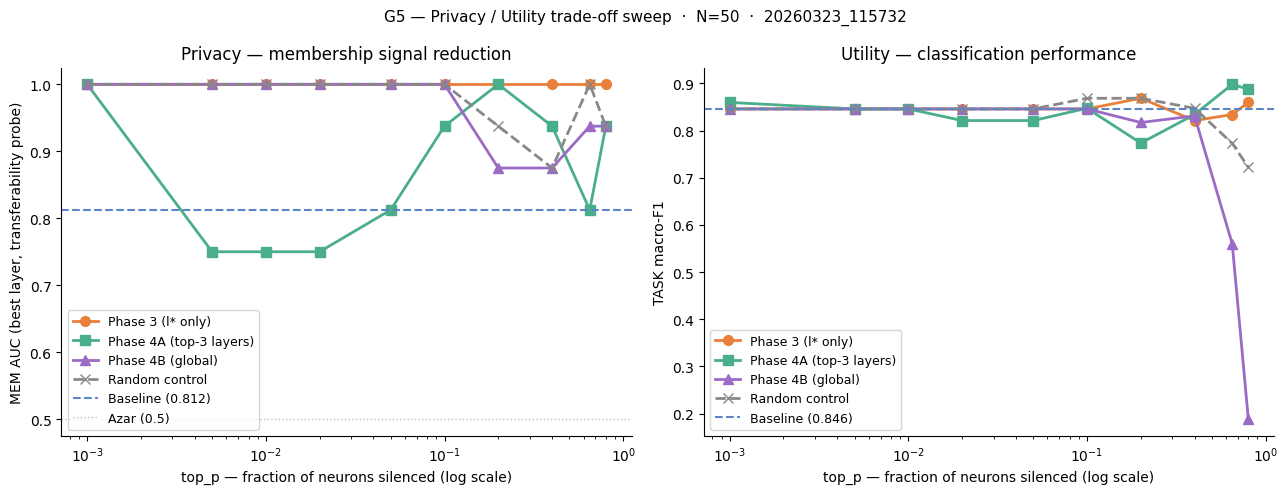

2026-03-23 16:04:43,949 - INFO - ✅ G5 saved: data/BigBird/figs_syn+lum/G5_sweep_20260323_115732.png


In [50]:
# ── Visualización del sweep (G5 sweet spot) ──────────────────────────────────

df_sw = pd.read_csv(f"{sweep_dir}/sweep_results_{RUN_TS}.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

experiments = [
    ("e1_p3",  "Phase 3 (l* only)",   PALETTE["phase3"],   "o-"),
    ("e2_p4a", "Phase 4A (top-3 layers)", PALETTE["phase4a"], "s-"),
    ("e3_p4b", "Phase 4B (global)",   PALETTE["phase4b"],  "^-"),
    ("e4_rnd", "Random control",      "#888888",           "x--"),
]

# Panel izquierdo: MEM AUC vs top_p
ax = axes[0]
for prefix, label, color, style in experiments:
    ax.plot(df_sw["top_p"], df_sw[f"{prefix}_best_auc_def"],
            style, color=color, label=label, linewidth=2, markersize=7)
ax.axhline(baseline_best_auc, color=PALETTE["baseline"], linestyle="--",
           linewidth=1.5, label=f"Baseline ({baseline_best_auc:.3f})")
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1, alpha=0.5, label="Azar (0.5)")
ax.set_xscale("log")
ax.set_xlabel("top_p — fraction of neurons silenced (log scale)")
ax.set_ylabel("MEM AUC (best layer, transferability probe)")
ax.set_title("Privacy — membership signal reduction")
ax.legend(fontsize=9)
sns.despine(ax=ax)

# Panel derecho: TASK F1 vs top_p
ax = axes[1]
for prefix, label, color, style in experiments:
    ax.plot(df_sw["top_p"], df_sw[f"{prefix}_macro_f1"],
            style, color=color, label=label, linewidth=2, markersize=7)
ax.axhline(baseline_f1, color=PALETTE["baseline"], linestyle="--",
           linewidth=1.5, label=f"Baseline ({baseline_f1:.3f})")
ax.set_xscale("log")
ax.set_xlabel("top_p — fraction of neurons silenced (log scale)")
ax.set_ylabel("TASK macro-F1")
ax.set_title("Utility — classification performance")
ax.legend(fontsize=9)
sns.despine(ax=ax)

fig.suptitle(
    f"G5 — Privacy / Utility trade-off sweep  ·  N={len(df_reduced)}  ·  {RUN_TS}",
    fontsize=11
)
plt.tight_layout()
fig_path = f"{figs}/G5_sweep_{RUN_TS}.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
logger.info(f"✅ G5 saved: {fig_path}")

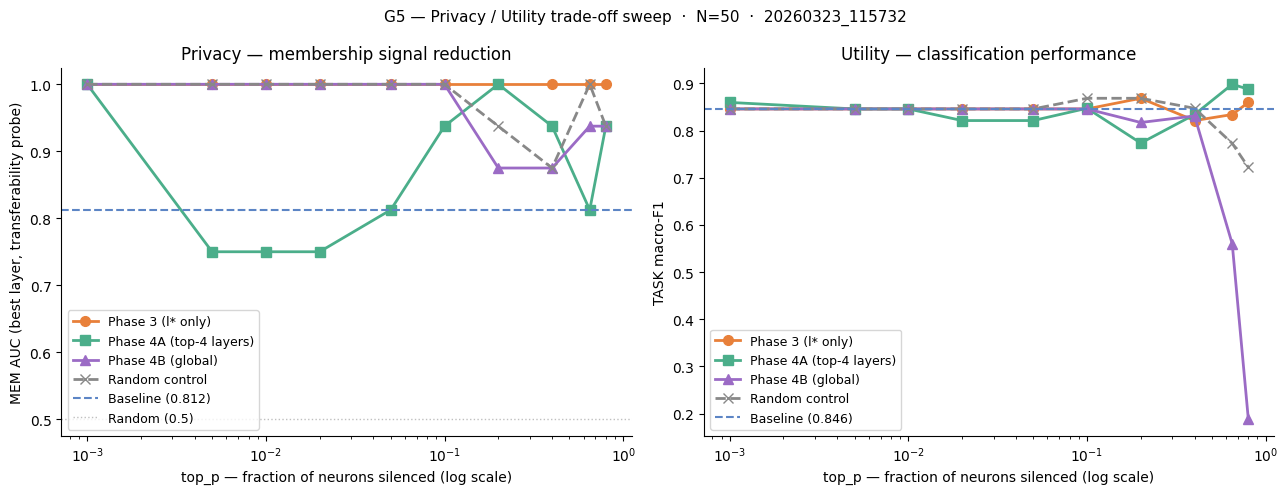

2026-03-23 17:28:40,784 - INFO - ✅ G5 saved: data/BigBird/figs_syn+lum/G5_sweep_20260323_115732.png


In [52]:
# ── G5: Sweet spot — privacy / utility trade-off sweep ───────────────────────

df_sw = pd.read_csv(f"{sweep_dir}/sweep_results_{RUN_TS}.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

experiments = [
    ("e1_p3",  "Phase 3 (l* only)",       PALETTE["phase3"],   "o-"),
    ("e2_p4a", f"Phase 4A (top-{K_LAYERS} layers)", PALETTE["phase4a"], "s-"),
    ("e3_p4b", "Phase 4B (global)",        PALETTE["phase4b"],  "^-"),
    ("e4_rnd", "Random control",           "#888888",           "x--"),
]

# Panel izquierdo: MEM AUC vs top_p
ax = axes[0]
for prefix, label, color, style in experiments:
    ax.plot(df_sw["top_p"], df_sw[f"{prefix}_best_auc_def"],
            style, color=color, label=label, linewidth=2, markersize=7)
ax.axhline(baseline_best_auc, color=PALETTE["baseline"], linestyle="--",
           linewidth=1.5, label=f"Baseline ({baseline_best_auc:.3f})")
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1, alpha=0.5, label="Random (0.5)")
ax.set_xscale("log")
ax.set_xlabel("top_p — fraction of neurons silenced (log scale)")
ax.set_ylabel("MEM AUC (best layer, transferability probe)")
ax.set_title("Privacy — membership signal reduction")
ax.legend(fontsize=9)
sns.despine(ax=ax)

# Panel derecho: TASK F1 vs top_p
ax = axes[1]
for prefix, label, color, style in experiments:
    ax.plot(df_sw["top_p"], df_sw[f"{prefix}_macro_f1"],
            style, color=color, label=label, linewidth=2, markersize=7)
ax.axhline(baseline_f1, color=PALETTE["baseline"], linestyle="--",
           linewidth=1.5, label=f"Baseline ({baseline_f1:.3f})")
ax.set_xscale("log")
ax.set_xlabel("top_p — fraction of neurons silenced (log scale)")
ax.set_ylabel("TASK macro-F1")
ax.set_title("Utility — classification performance")
ax.legend(fontsize=9)
sns.despine(ax=ax)

fig.suptitle(
    f"G5 — Privacy / Utility trade-off sweep  ·  N={len(df_reduced)}  ·  {RUN_TS}",
    fontsize=11
)
plt.tight_layout()
fig_path = f"{figs}/G5_sweep_{RUN_TS}.png"
os.makedirs(figs, exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
logger.info(f"✅ G5 saved: {fig_path}")

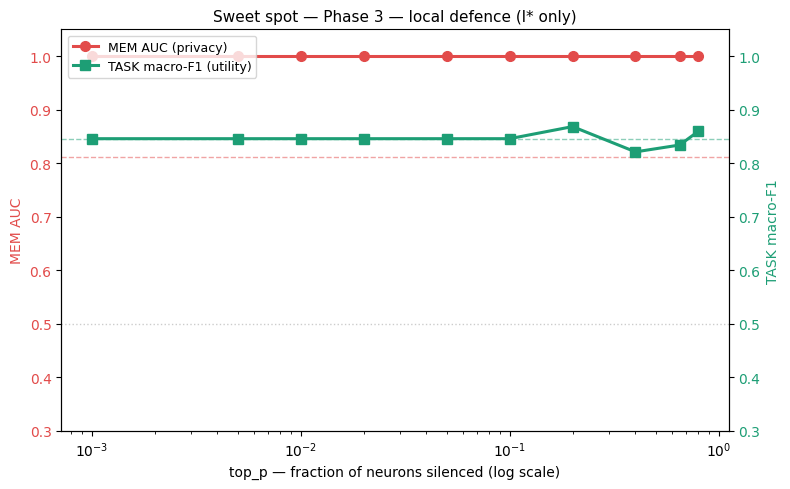

2026-03-23 18:09:13,220 - INFO - ✅ Saved: data/BigBird/figs_syn+lum/G5_e1_p3_sweetspot_20260323_115732.png


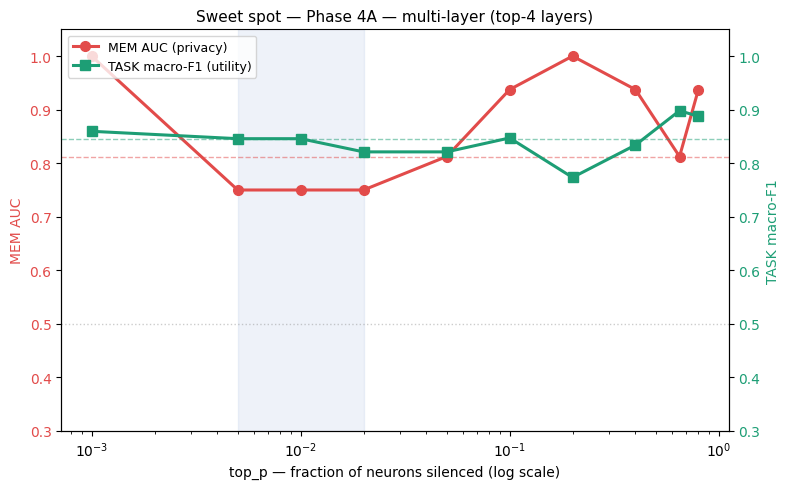

2026-03-23 18:09:13,460 - INFO - ✅ Saved: data/BigBird/figs_syn+lum/G5_e2_p4a_sweetspot_20260323_115732.png


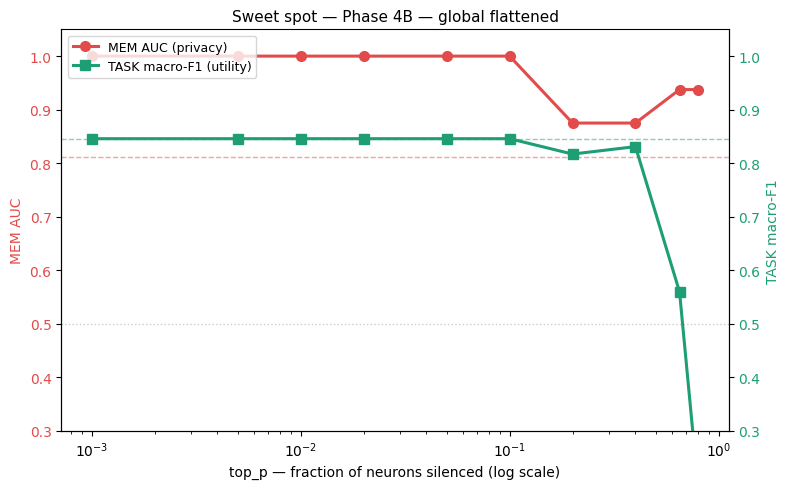

2026-03-23 18:09:13,710 - INFO - ✅ Saved: data/BigBird/figs_syn+lum/G5_e3_p4b_sweetspot_20260323_115732.png


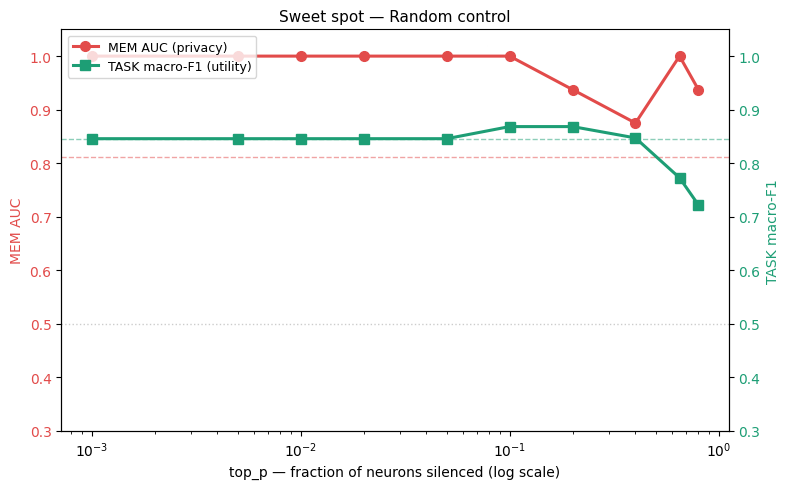

2026-03-23 18:09:13,984 - INFO - ✅ Saved: data/BigBird/figs_syn+lum/G5_e4_rnd_sweetspot_20260323_115732.png


In [55]:
# ── G5: Sweet spot — una gráfica por fase ────────────────────────────────────

df_sw = pd.read_csv(f"{sweep_dir}/sweep_results_{RUN_TS}.csv")

phases = [
    ("e1_p3",  "Phase 3 — local defence (l* only)"),
    ("e2_p4a", f"Phase 4A — multi-layer (top-{K_LAYERS} layers)"),
    ("e3_p4b", "Phase 4B — global flattened"),
    ("e4_rnd", "Random control"),
]

for prefix, title in phases:
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax2 = ax1.twinx()

    mem_vals  = df_sw[f"{prefix}_best_auc_def"].values
    task_vals = df_sw[f"{prefix}_macro_f1"].values
    x         = df_sw["top_p"].values

    # MEM AUC — eje izquierdo
    l1, = ax1.plot(x, mem_vals,  "o-", color="#E24B4A", linewidth=2.2,
                   markersize=7, label="MEM AUC (privacy)")
    ax1.axhline(baseline_best_auc, color="#E24B4A", linestyle="--",
                linewidth=1, alpha=0.5, label=f"MEM baseline ({baseline_best_auc:.3f})")
    ax1.axhline(0.5, color="gray", linestyle=":", linewidth=1,
                alpha=0.4, label="Random (0.5)")
    ax1.set_ylabel("MEM AUC", color="#E24B4A")
    ax1.tick_params(axis="y", labelcolor="#E24B4A")
    ax1.set_ylim(0.3, 1.05)

    # TASK F1 — eje derecho
    l2, = ax2.plot(x, task_vals, "s-", color="#1D9E75", linewidth=2.2,
                   markersize=7, label="TASK macro-F1 (utility)")
    ax2.axhline(baseline_f1, color="#1D9E75", linestyle="--",
                linewidth=1, alpha=0.5, label=f"TASK baseline ({baseline_f1:.3f})")
    ax2.set_ylabel("TASK macro-F1", color="#1D9E75")
    ax2.tick_params(axis="y", labelcolor="#1D9E75")
    ax2.set_ylim(0.3, 1.05)

    # Zona sweet spot: donde MEM AUC baja significativamente y TASK F1 se mantiene
    # Criterio: MEM AUC < baseline y TASK F1 >= 95% del baseline
    sweet_mask = (mem_vals < baseline_best_auc) & (task_vals >= 0.95 * baseline_f1)
    if sweet_mask.any():
        x_sweet = x[sweet_mask]
        ax1.axvspan(x_sweet.min(), x_sweet.max(),
                    alpha=0.10, color="#5C85C5", label="Sweet spot zone")

    ax1.set_xscale("log")
    ax1.set_xlabel("top_p — fraction of neurons silenced (log scale)")

    # Leyenda combinada
    lines = [l1, l2]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, fontsize=9, loc="upper left")

    ax1.set_title(f"Sweet spot — {title}", fontsize=11)
    sns.despine(ax=ax1, right=False)

    plt.tight_layout()
    fig_path = f"{figs}/G5_{prefix}_sweetspot_{RUN_TS}.png"
    os.makedirs(figs, exist_ok=True)
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    logger.info(f"✅ Saved: {fig_path}")

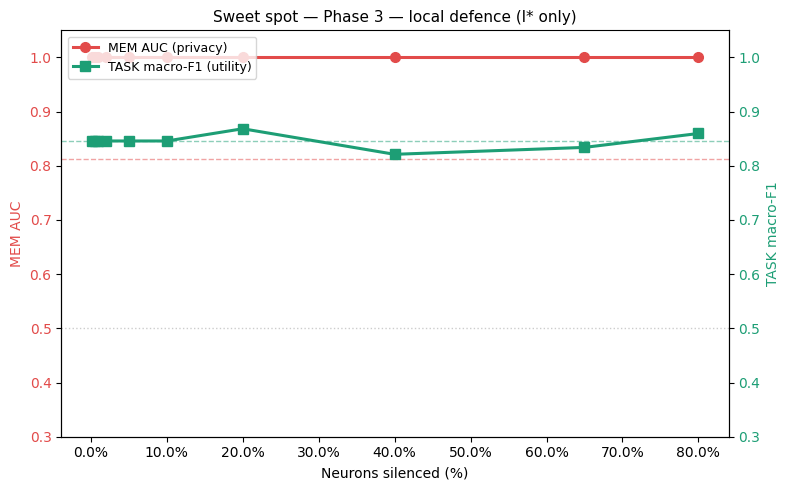

2026-03-23 18:09:16,273 - INFO - ✅ Saved: data/BigBird/figs_syn+lum/G5_e1_p3_sweetspot_20260323_115732.png


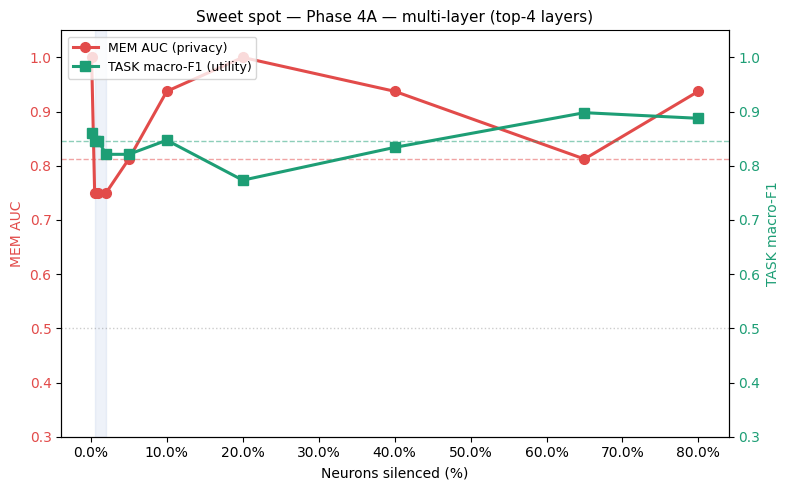

2026-03-23 18:09:16,437 - INFO - ✅ Saved: data/BigBird/figs_syn+lum/G5_e2_p4a_sweetspot_20260323_115732.png


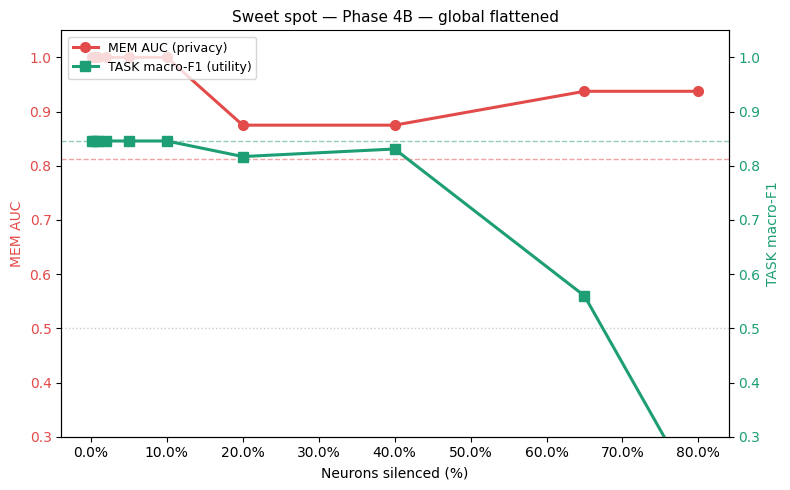

2026-03-23 18:09:16,600 - INFO - ✅ Saved: data/BigBird/figs_syn+lum/G5_e3_p4b_sweetspot_20260323_115732.png


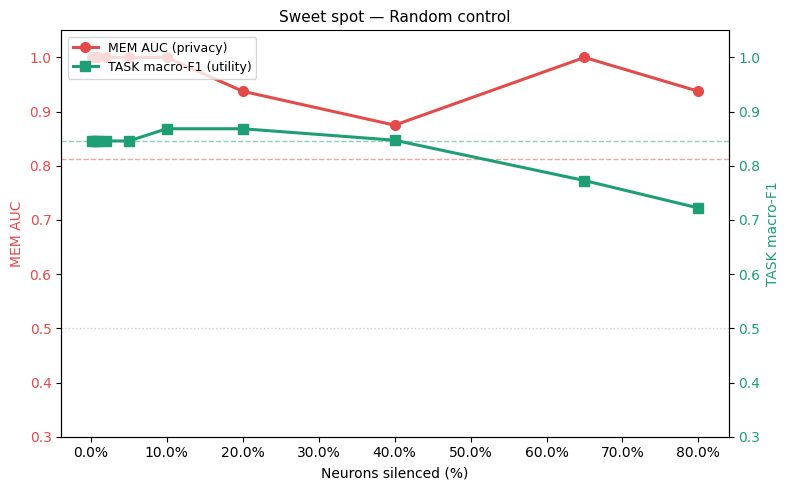

2026-03-23 18:09:16,832 - INFO - ✅ Saved: data/BigBird/figs_syn+lum/G5_e4_rnd_sweetspot_20260323_115732.png


In [56]:
# ── G5: Sweet spot — una gráfica por fase ────────────────────────────────────

df_sw = pd.read_csv(f"{sweep_dir}/sweep_results_{RUN_TS}.csv")

phases = [
    ("e1_p3",  "Phase 3 — local defence (l* only)"),
    ("e2_p4a", f"Phase 4A — multi-layer (top-{K_LAYERS} layers)"),
    ("e3_p4b", "Phase 4B — global flattened"),
    ("e4_rnd", "Random control"),
]

for prefix, title in phases:
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax2 = ax1.twinx()

    mem_vals  = df_sw[f"{prefix}_best_auc_def"].values
    task_vals = df_sw[f"{prefix}_macro_f1"].values
    x_pct     = df_sw["top_p"].values * 100   # convertir a porcentaje real

    # MEM AUC — eje izquierdo
    l1, = ax1.plot(x_pct, mem_vals, "o-", color="#E24B4A", linewidth=2.2,
                   markersize=7, label="MEM AUC (privacy)")
    ax1.axhline(baseline_best_auc, color="#E24B4A", linestyle="--",
                linewidth=1, alpha=0.5, label=f"MEM baseline ({baseline_best_auc:.3f})")
    ax1.axhline(0.5, color="gray", linestyle=":", linewidth=1,
                alpha=0.4, label="Random (0.5)")
    ax1.set_ylabel("MEM AUC", color="#E24B4A")
    ax1.tick_params(axis="y", labelcolor="#E24B4A")
    ax1.set_ylim(0.3, 1.05)

    # TASK F1 — eje derecho
    l2, = ax2.plot(x_pct, task_vals, "s-", color="#1D9E75", linewidth=2.2,
                   markersize=7, label="TASK macro-F1 (utility)")
    ax2.axhline(baseline_f1, color="#1D9E75", linestyle="--",
                linewidth=1, alpha=0.5, label=f"TASK baseline ({baseline_f1:.3f})")
    ax2.set_ylabel("TASK macro-F1", color="#1D9E75")
    ax2.tick_params(axis="y", labelcolor="#1D9E75")
    ax2.set_ylim(0.3, 1.05)

    # Zona sweet spot
    sweet_mask = (mem_vals < baseline_best_auc) & (task_vals >= 0.95 * baseline_f1)
    if sweet_mask.any():
        x_sweet = x_pct[sweet_mask]
        ax1.axvspan(x_sweet.min(), x_sweet.max(),
                    alpha=0.10, color="#5C85C5", label="Sweet spot zone")

    # Eje X en porcentaje real
    ax1.set_xlabel("Neurons silenced (%)")
    ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f}%"))

    # Leyenda combinada
    lines  = [l1, l2]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, fontsize=9, loc="upper left")

    ax1.set_title(f"Sweet spot — {title}", fontsize=11)
    sns.despine(ax=ax1, right=False)

    plt.tight_layout()
    fig_path = f"{figs}/G5_{prefix}_sweetspot_{RUN_TS}.png"
    os.makedirs(figs, exist_ok=True)
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    logger.info(f"✅ Saved: {fig_path}")

# Graphics

/var/folders/y4/zbxddgn52lx1dx5ktc7jch6m0000gn/T/ipykernel_7318/1484173.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(x_labels, rotation=40, ha="right")


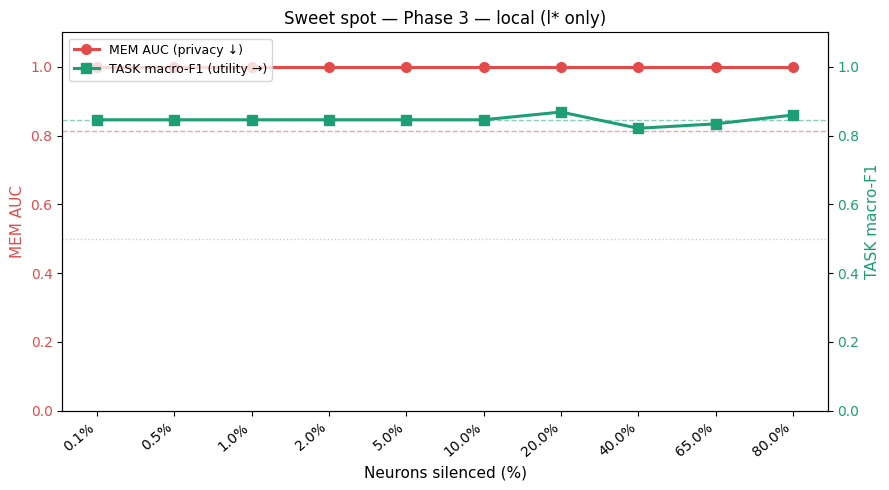

2026-03-23 18:23:29,728 - INFO - ✅ data/BigBird/figs_syn+lum/G5_e1_p3_sweetspot_20260323_115732.png
/var/folders/y4/zbxddgn52lx1dx5ktc7jch6m0000gn/T/ipykernel_7318/1484173.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(x_labels, rotation=40, ha="right")


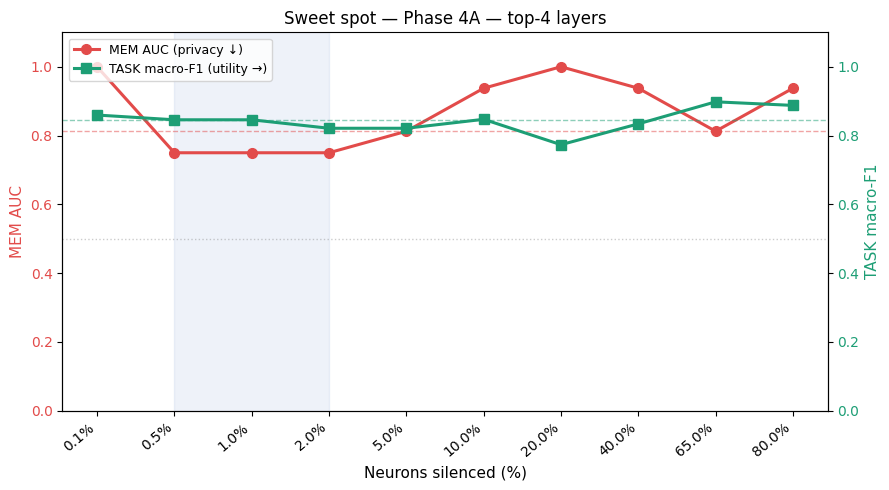

2026-03-23 18:23:29,868 - INFO - ✅ data/BigBird/figs_syn+lum/G5_e2_p4a_sweetspot_20260323_115732.png
/var/folders/y4/zbxddgn52lx1dx5ktc7jch6m0000gn/T/ipykernel_7318/1484173.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(x_labels, rotation=40, ha="right")


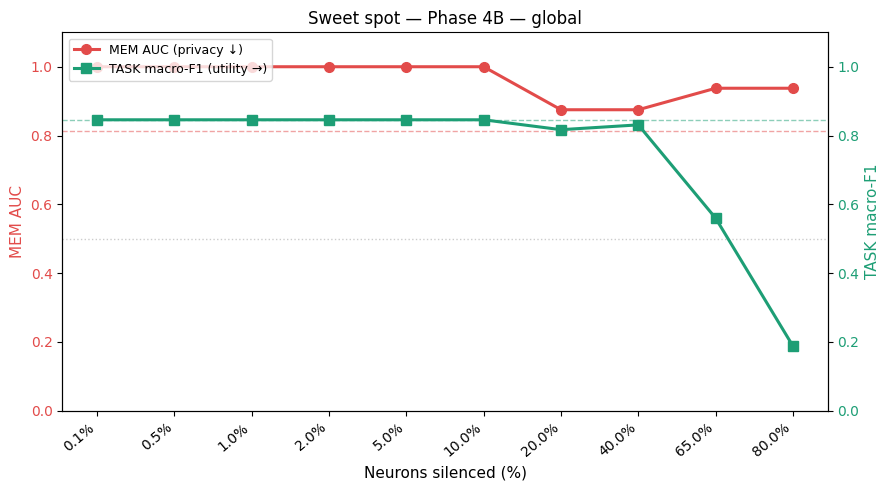

2026-03-23 18:23:30,165 - INFO - ✅ data/BigBird/figs_syn+lum/G5_e3_p4b_sweetspot_20260323_115732.png
/var/folders/y4/zbxddgn52lx1dx5ktc7jch6m0000gn/T/ipykernel_7318/1484173.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(x_labels, rotation=40, ha="right")


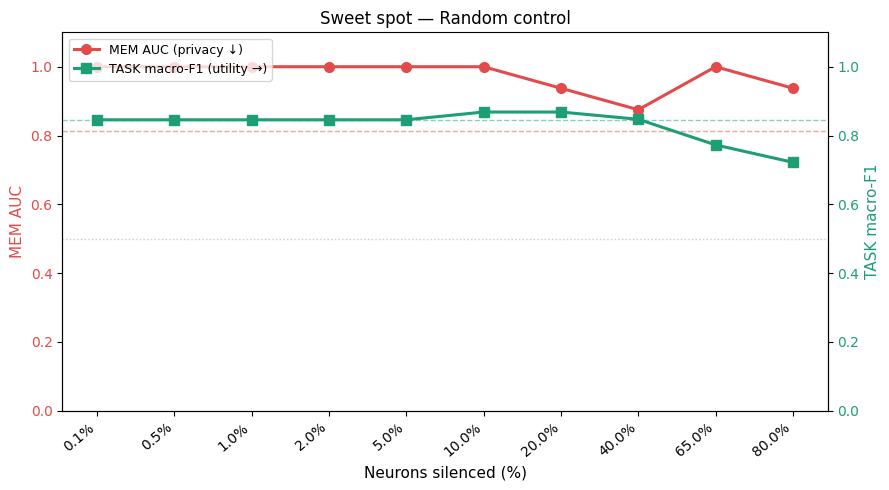

2026-03-23 18:23:30,310 - INFO - ✅ data/BigBird/figs_syn+lum/G5_e4_rnd_sweetspot_20260323_115732.png


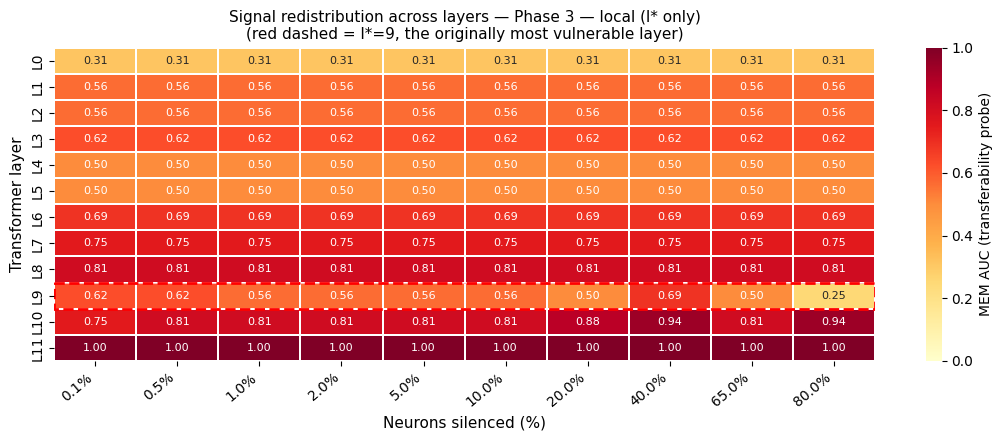

2026-03-23 18:23:30,564 - INFO - ✅ data/BigBird/figs_syn+lum/G_heatmap_e1_p3_20260323_115732.png


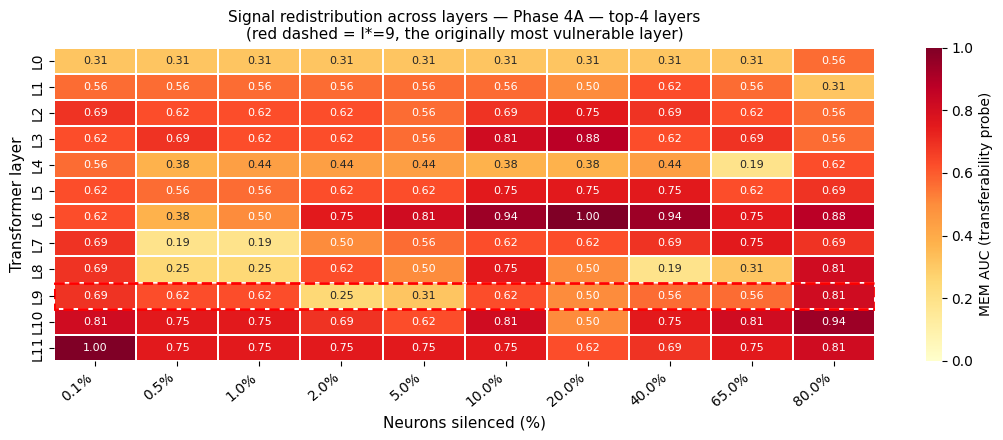

2026-03-23 18:23:30,810 - INFO - ✅ data/BigBird/figs_syn+lum/G_heatmap_e2_p4a_20260323_115732.png


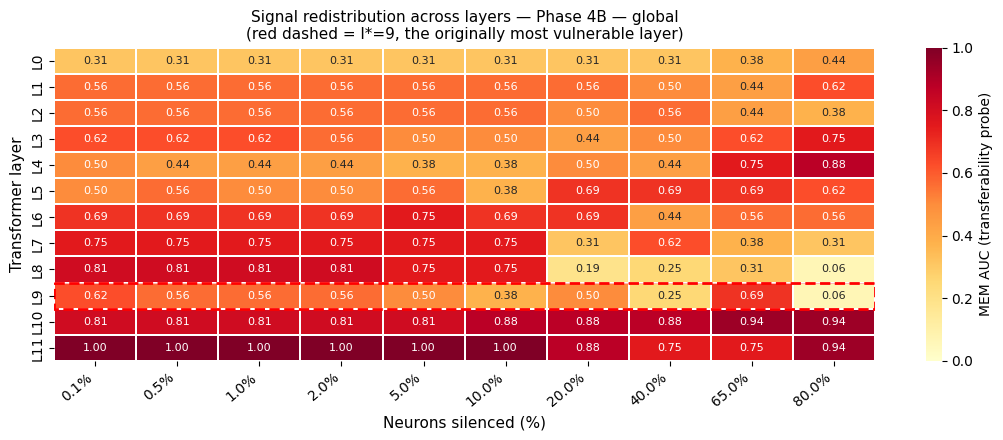

2026-03-23 18:23:31,079 - INFO - ✅ data/BigBird/figs_syn+lum/G_heatmap_e3_p4b_20260323_115732.png


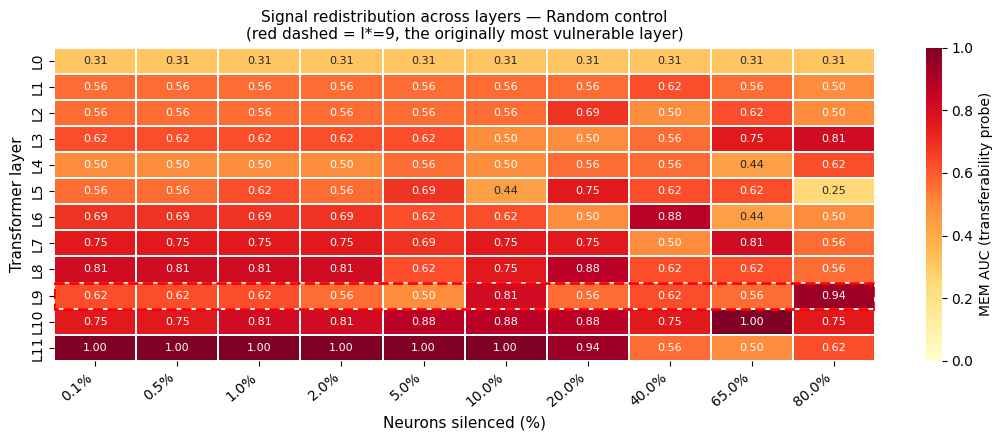

2026-03-23 18:23:31,331 - INFO - ✅ data/BigBird/figs_syn+lum/G_heatmap_e4_rnd_20260323_115732.png


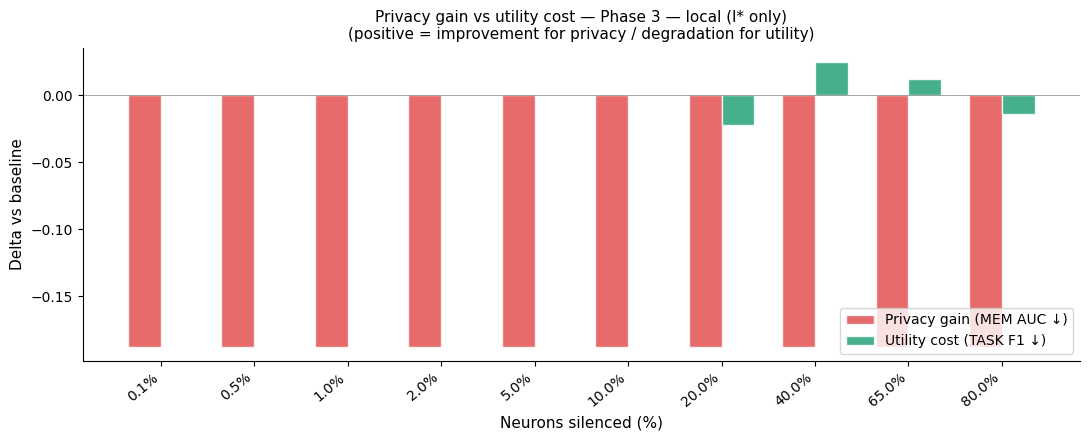

2026-03-23 18:23:31,463 - INFO - ✅ data/BigBird/figs_syn+lum/G_delta_e1_p3_20260323_115732.png


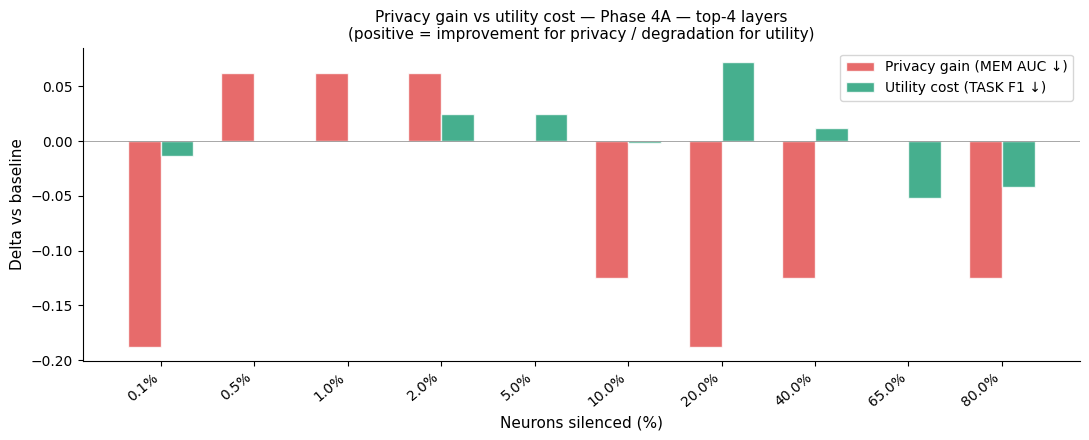

2026-03-23 18:23:31,595 - INFO - ✅ data/BigBird/figs_syn+lum/G_delta_e2_p4a_20260323_115732.png


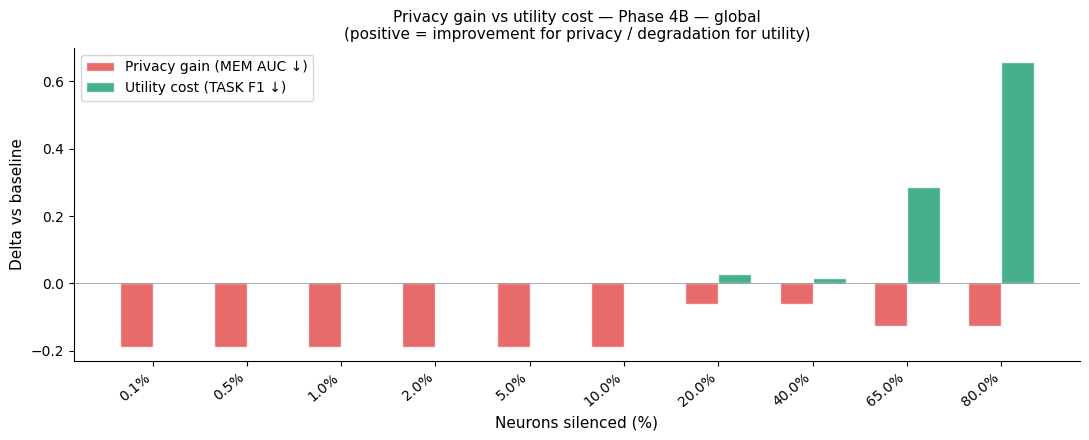

2026-03-23 18:23:31,750 - INFO - ✅ data/BigBird/figs_syn+lum/G_delta_e3_p4b_20260323_115732.png


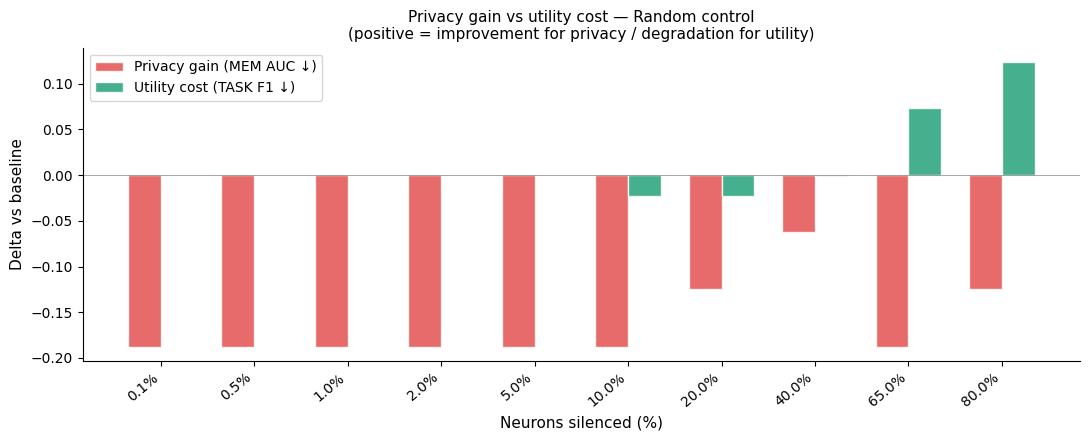

2026-03-23 18:23:31,881 - INFO - ✅ data/BigBird/figs_syn+lum/G_delta_e4_rnd_20260323_115732.png


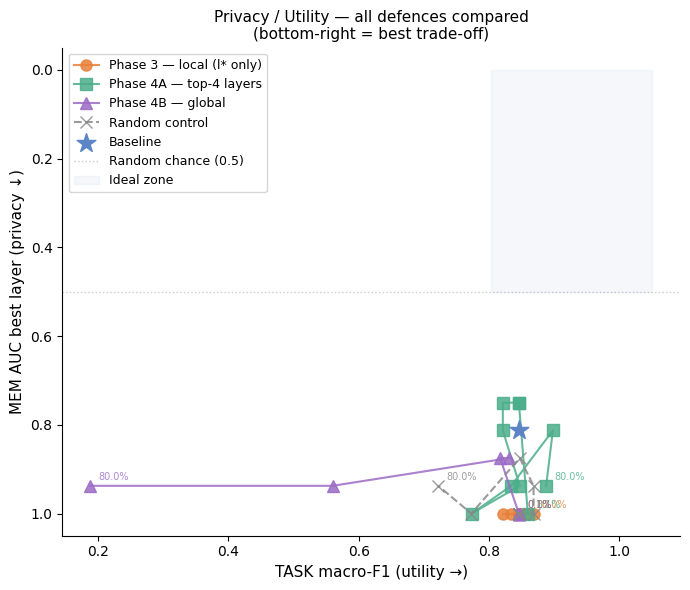

2026-03-23 18:23:32,020 - INFO - ✅ data/BigBird/figs_syn+lum/G_compare_all_20260323_115732.png
2026-03-23 18:23:32,020 - INFO - 
✅ All figures saved to data/BigBird/figs_syn+lum/


In [58]:
# ═══════════════════════════════════════════════════════════════════════════
# GRÁFICAS DE ANÁLISIS DEL SWEEP
# ═══════════════════════════════════════════════════════════════════════════

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

# ── Cargar datos ──────────────────────────────────────────────────────────────
df_sw = pd.read_csv(f"{sweep_dir}/sweep_results_{RUN_TS}.csv")


x_pct    = np.arange(len(df_sw))
x_labels = [f"{v*100:.1f}%" for v in df_sw["top_p"].values]

PHASES = [
    ("e1_p3",  "Phase 3 — local (l* only)",         PALETTE["phase3"],   "o-"),
    ("e2_p4a", f"Phase 4A — top-{K_LAYERS} layers", PALETTE["phase4a"],  "s-"),
    ("e3_p4b", "Phase 4B — global",                 PALETTE["phase4b"],  "^-"),
    ("e4_rnd", "Random control",                    "#888888",           "x--"),
]

os.makedirs(figs, exist_ok=True)


# ─────────────────────────────────────────────────────────────────────────────
# G5: Sweet spot — una gráfica por fase (MEM AUC + TASK F1 en doble eje Y)
# Muestra el equilibrio entre privacidad y utilidad a lo largo del sweep
# ─────────────────────────────────────────────────────────────────────────────
for prefix, title, color, _ in PHASES:
    fig, ax1 = plt.subplots(figsize=(9, 5))
    ax2 = ax1.twinx()

    mem_vals  = df_sw[f"{prefix}_best_auc_def"].values
    task_vals = df_sw[f"{prefix}_macro_f1"].values

    l1, = ax1.plot(x_pct, mem_vals,  "o-", color="#E24B4A", linewidth=2.2,
                   markersize=7, label="MEM AUC (privacy ↓)")
    ax1.axhline(baseline_best_auc, color="#E24B4A", linestyle="--",
                linewidth=1, alpha=0.5, label=f"MEM baseline ({baseline_best_auc:.3f})")
    ax1.axhline(0.5, color="gray", linestyle=":", linewidth=1,
                alpha=0.4, label="Random chance (0.5)")
    ax1.set_ylabel("MEM AUC", color="#E24B4A", fontsize=11)
    ax1.tick_params(axis="y", labelcolor="#E24B4A")
    ax1.set_ylim(0.0, 1.1)

    l2, = ax2.plot(x_pct, task_vals, "s-", color="#1D9E75", linewidth=2.2,
                   markersize=7, label="TASK macro-F1 (utility →)")
    ax2.axhline(baseline_f1, color="#1D9E75", linestyle="--",
                linewidth=1, alpha=0.5, label=f"TASK baseline ({baseline_f1:.3f})")
    ax2.set_ylabel("TASK macro-F1", color="#1D9E75", fontsize=11)
    ax2.tick_params(axis="y", labelcolor="#1D9E75")
    ax2.set_ylim(0.0, 1.1)

    # Zona sweet spot: MEM baja del baseline Y TASK >= 95% del baseline
    sweet_mask = (mem_vals < baseline_best_auc) & (task_vals >= 0.95 * baseline_f1)
    if sweet_mask.any():
        x_sweet = x_pct[sweet_mask]
        ax1.axvspan(x_sweet.min(), x_sweet.max(),
                    alpha=0.10, color="#5C85C5", label="Sweet spot")

    ax1.set_xlabel("Neurons silenced (%)", fontsize=11)
    #ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f}%"))
    ax1.set_xticklabels(x_labels, rotation=40, ha="right")
    ax1.set_xticks(x_pct)
    plt.setp(ax1.get_xticklabels(), rotation=40, ha="right")

    lines  = [l1, l2]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, fontsize=9, loc="upper left")
    ax1.set_title(f"Sweet spot — {title}", fontsize=12)
    sns.despine(ax=ax1, right=False)
    plt.tight_layout()
    path = f"{figs}/G5_{prefix}_sweetspot_{RUN_TS}.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    logger.info(f"✅ {path}")


# ─────────────────────────────────────────────────────────────────────────────
# G_AUC_HEATMAP: Redistribución de señal de membership por capa
# Para cada fase, heatmap (capa × top_p) mostrando cómo el AUC se mueve
# entre capas a medida que silencias más neuronas
# ─────────────────────────────────────────────────────────────────────────────
for prefix, title, color, _ in PHASES:
    n_layers = 12
    heatmap_data = np.zeros((n_layers, len(df_sw)))

    for j, row in df_sw.iterrows():
        auc_dict = json.loads(row[f"{prefix}_auc_per_layer"])
        for layer_id, auc_val in auc_dict.items():
            heatmap_data[int(layer_id), j] = float(auc_val)

    fig, ax = plt.subplots(figsize=(11, 4.5))
    im = sns.heatmap(
        heatmap_data,
        ax=ax,
        cmap="YlOrRd",
        vmin=0.0, vmax=1.0,
        annot=True, fmt=".2f",
        annot_kws={"size": 8},
        xticklabels=x_labels,
        yticklabels=[f"L{i}" for i in range(n_layers)],
        linewidths=0.3,
        cbar_kws={"label": "MEM AUC (transferability probe)"},
    )
    # Marcar l* con borde rojo
    ax.add_patch(plt.Rectangle(
        (0, int(l_star)), len(df_sw), 1,
        fill=False, edgecolor="red", lw=2, linestyle="--"
    ))
    ax.axhline(int(l_star), color="red", linewidth=0.5, alpha=0.4)

    plt.setp(ax.get_xticklabels(), rotation=40, ha="right")
    ax.set_xlabel("Neurons silenced (%)", fontsize=11)
    ax.set_ylabel("Transformer layer", fontsize=11)
    ax.set_title(
        f"Signal redistribution across layers — {title}\n"
        f"(red dashed = l*={int(l_star)}, the originally most vulnerable layer)",
        fontsize=11
    )
    plt.tight_layout()
    path = f"{figs}/G_heatmap_{prefix}_{RUN_TS}.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    logger.info(f"✅ {path}")


# ─────────────────────────────────────────────────────────────────────────────
# G_DELTA: Trade-off resumido — reducción de AUC vs coste en utilidad
# Para cada top_p, barras agrupadas mostrando delta_mem (privacidad ganada)
# y delta_f1 (utilidad perdida). Ideal: delta_mem alto, delta_f1 cercano a 0
# ─────────────────────────────────────────────────────────────────────────────
for prefix, title, color, _ in PHASES:
    delta_mem = baseline_best_auc - df_sw[f"{prefix}_best_auc_def"].values
    delta_f1  = baseline_f1       - df_sw[f"{prefix}_macro_f1"].values

    x    = np.arange(len(x_pct))
    w    = 0.35
    fig, ax = plt.subplots(figsize=(11, 4.5))

    bars1 = ax.bar(x - w/2, delta_mem, w, label="Privacy gain (MEM AUC ↓)",
                   color="#E24B4A", alpha=0.82, edgecolor="white")
    bars2 = ax.bar(x + w/2, delta_f1,  w, label="Utility cost (TASK F1 ↓)",
                   color="#1D9E75", alpha=0.82, edgecolor="white")

    ax.axhline(0, color="black", linewidth=0.6, alpha=0.4)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=40, ha="right")
    ax.set_xlabel("Neurons silenced (%)", fontsize=11)
    ax.set_ylabel("Delta vs baseline", fontsize=11)
    ax.set_title(
        f"Privacy gain vs utility cost — {title}\n"
        f"(positive = improvement for privacy / degradation for utility)",
        fontsize=11
    )
    ax.legend(fontsize=10)
    sns.despine(ax=ax)
    plt.tight_layout()
    path = f"{figs}/G_delta_{prefix}_{RUN_TS}.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    logger.info(f"✅ {path}")


# ─────────────────────────────────────────────────────────────────────────────
# G_COMPARE: Las 4 fases en un scatter MEM AUC vs TASK F1
# Cada punto = un top_p. Punto ideal: esquina inferior derecha (MEM bajo, F1 alto)
# Permite comparar qué estrategia de defensa domina a las demás
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

for prefix, label, color, style in PHASES:
    mem_vals  = df_sw[f"{prefix}_best_auc_def"].values
    task_vals = df_sw[f"{prefix}_macro_f1"].values
    ax.plot(task_vals, mem_vals, style, color=color, label=label,
            linewidth=1.5, markersize=8, alpha=0.85)
    # Anotar el primer y último punto con el top_p
    for idx in [0, len(df_sw) - 1]:
        ax.annotate(
            f"{df_sw['top_p'].iloc[idx]*100:.1f}%",
            (task_vals[idx], mem_vals[idx]),
            textcoords="offset points", xytext=(6, 4),
            fontsize=7, color=color, alpha=0.8,
        )

# Punto baseline
ax.scatter([baseline_f1], [baseline_best_auc], marker="*", s=200,
           color=PALETTE["baseline"], zorder=5, label=f"Baseline")

ax.axhline(0.5, color="gray", linestyle=":", linewidth=1,
           alpha=0.4, label="Random chance (0.5)")

# Zona ideal: bajo MEM AUC y alto F1
ax.fill_betweenx([0.0, 0.5], 0.95 * baseline_f1, 1.05,
                 alpha=0.06, color="#5C85C5", label="Ideal zone")

ax.set_xlabel("TASK macro-F1 (utility →)", fontsize=11)
ax.set_ylabel("MEM AUC best layer (privacy ↓)", fontsize=11)
ax.set_title(
    "Privacy / Utility — all defences compared\n"
    "(bottom-right = best trade-off)",
    fontsize=11
)
ax.legend(fontsize=9, loc="upper left")
ax.invert_yaxis()   # MEM AUC bajo = mejor privacidad = arriba del gráfico
sns.despine(ax=ax)
plt.tight_layout()
path = f"{figs}/G_compare_all_{RUN_TS}.png"
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
logger.info(f"✅ {path}")

logger.info(f"\n✅ All figures saved to {figs}/")